In [1]:
import os
import optuna
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import logging
import psutil
import random
import hdbscan
import warnings
import itertools
from multiprocessing import cpu_count
from sklearn.cluster import Birch, KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, adjusted_mutual_info_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.utils import resample
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from scipy.spatial.distance import cdist
import math
import seaborn as sns
from scipy.stats import entropy

c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def set_global_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Global Seed set to {seed}")


set_global_seed(42)

Global Seed set to 42


In [3]:
def set_polite_process(target_cpu_percent=0.7):
    total_cores = cpu_count()
    allowed_cores = max(1, int(total_cores * target_cpu_percent))
    
    p = psutil.Process(os.getpid())
    try:
        if os.name == 'nt': 
            p.nice(psutil.BELOW_NORMAL_PRIORITY_CLASS)
        else:
            p.nice(10)
        print(f"System Priority Lowered")
    except Exception as e:
        print(f"Could not set process priority: {e}")

    print(f"CPU Limit Set: Using {allowed_cores} out of {total_cores} cores ({int(target_cpu_percent*100)}%).")
    return allowed_cores


n_jobs_polite = set_polite_process(target_cpu_percent=0.7)

System Priority Lowered
CPU Limit Set: Using 8 out of 12 cores (70%).


In [2]:
# 1. LOAD DATA

input_file = "final_dataset_cleaned.csv" 
df = pd.read_csv(input_file)

print(f"Initial Shape: {df.shape}")
print("-" * 30)

# 2. DUPLICATE CHECK
if df['asn'].duplicated().any():
    print(f"Found {df['asn'].duplicated().sum()} duplicate ASNs. Removing...")
    df = df.drop_duplicates(subset=['asn'], keep='first')
else:
    print("No duplicate ASNs found.")

# 3. MISSING VALUE CHECK (Empty Cells)
missing = df.isnull().sum()
if missing.sum() > 0:
    print("\nFound Missing Values:")
    print(missing[missing > 0])
    
    # Strategy: Fill categorical with "Unknown", numerical with 0
    num_cols = df.select_dtypes(include=[np.number]).columns
    cat_cols = df.select_dtypes(include=['object']).columns
    
    df[num_cols] = df[num_cols].fillna(0)
    df[cat_cols] = df[cat_cols].fillna('Unknown')
    print("   -> Filled missing values.")
else:
    print("No empty cells (NaNs) found.")

# 4. INFINITE VALUE CHECK
num_df = df.select_dtypes(include=[np.number])
if np.isinf(num_df).values.any():
    print("\nFound Infinite (inf) values. Replacing with 0...")
    df = df.replace([np.inf, -np.inf], 0)
else:
    print("No infinite values found.")

# 5. DATA TYPE & SANITY CHECK
df['asn'] = df['asn'].astype(int)

neg_counts = (num_df < 0).sum().sum()
if neg_counts > 0:
    print(f"\nFound {neg_counts} negative values (impossible for counts). Clipping to 0...")
    num_cols = df.select_dtypes(include=[np.number]).columns
    df[num_cols] = df[num_cols].clip(lower=0)
else:
    print("No negative values found.")

# 6. FINAL REVIEW
print("\n" + "="*30)
print("FINAL DATASET STATUS")
print("="*30)
print(df.info())
print("\nSample Rows:")
display(df.head()) 

Initial Shape: (78643, 15)
------------------------------
No duplicate ASNs found.
No empty cells (NaNs) found.
No infinite values found.
No negative values found.

FINAL DATASET STATUS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78643 entries, 0 to 78642
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   asn                  78643 non-null  int64  
 1   country              78643 non-null  object 
 2   provider_count       78643 non-null  int64  
 3   customer_count       78643 non-null  int64  
 4   peer_count           78643 non-null  int64  
 5   peering_ratio        78643 non-null  float64
 6   total_ip_space       78643 non-null  float64
 7   prefix_count         78643 non-null  float64
 8   fragmentation_index  78643 non-null  float64
 9   ix_count             78643 non-null  float64
 10  facility_count       78643 non-null  float64
 11  net_type             78643 non-null  object 
 12  

,asn,country,provider_count,customer_count,peer_count,peering_ratio,total_ip_space,prefix_count,fragmentation_index,ix_count,facility_count,net_type,status_rir,asn_age_days,is_drop_listed
0,1,US,7,4,3,0.375000,11440.0,53.0,4.632867,0.0,0.0,Unknown,assigned,8851.0,0.0
1,11537,US,1,108,12,6.000000,7224.0,16.0,2.214839,2.0,9.0,Educational/Research,assigned,9944.0,0.0
2,25139,MZ,5,4,20,3.333333,73728.0,4.0,0.054253,2.0,3.0,Content,allocated,8535.0,0.0
3,147167,ID,2,0,0,0.000000,0.0,0.0,0.000000,0.0,0.0,Unknown,Unknown,0.0,0.0
4,203066,PL,1,0,3,1.500000,256.0,1.0,3.906250,0.0,0.0,Unknown,allocated,3539.0,0.0


In [3]:
# FEATURE ENCODING

# 1. ENCODE NET_TYPE
maturity_map = {
    'NSP': 5,
    'Cable/DSL/ISP': 5,
    'Content': 4,
    'Government': 3,
    'Enterprise': 2,
    'Educational/Research': 1,
    'Non-Profit': 0,
    'Route Server': 0,
    'Unknown': 0
}

df['security_maturity_score'] = df['net_type'].map(maturity_map).fillna(0).astype(int)

# 2. ENCODE STATUS_RIR
# 1 = Allocated (Infrastructure Owner), 0 = Assigned/Unknown
df['is_allocated'] = (df['status_rir'] == 'allocated').astype(int)

# 3. ENCODE COUNTRY (Frequency Rank)
# Converts "Country" into "Ecosystem Size"
# This provides a mathematical distance between jurisdictions without one-hot encoding.
country_counts = df['country'].value_counts()
country_ranks = country_counts.rank(method='min', ascending=False)
df['country_rank'] = df['country'].map(country_ranks).astype(int)

# 4. CLEANUP & SEPARATION
# Drop original string columns
cols_to_drop = ['net_type', 'status_rir', 'country']
df_encoded = df.drop(columns=cols_to_drop)


# FEATURES_FOR_CLUSTERING: The actual inputs the model will see
features_for_clustering = [
    'provider_count', 'customer_count', 'peer_count', 'peering_ratio',
    'total_ip_space', 'prefix_count', 'fragmentation_index',
    'ix_count', 'facility_count',
    'asn_age_days', 
    'security_maturity_score', 'is_allocated', 'country_rank'
]

# LABELS_FOR_ANALYSIS: Metadata hidden from the model but used to check results
labels_for_analysis = ['asn', 'org_name', 'is_drop_listed']

print("Encoding Complete.")
print(f"Training Features: {len(features_for_clustering)}")
print("-" * 30)


display(df_encoded.head())

Encoding Complete.
Training Features: 13
------------------------------


,asn,provider_count,customer_count,peer_count,peering_ratio,total_ip_space,prefix_count,fragmentation_index,ix_count,facility_count,asn_age_days,is_drop_listed,security_maturity_score,is_allocated,country_rank
0,1,7,4,3,0.375000,11440.0,53.0,4.632867,0.0,0.0,8851.0,0.0,0,0,1
1,11537,1,108,12,6.000000,7224.0,16.0,2.214839,2.0,9.0,9944.0,0.0,1,0,1
2,25139,5,4,20,3.333333,73728.0,4.0,0.054253,2.0,3.0,8535.0,0.0,4,1,110
3,147167,2,0,0,0.000000,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0,0,5
4,203066,1,0,3,1.500000,256.0,1.0,3.906250,0.0,0.0,3539.0,0.0,0,1,7


Log-transformation applied to count features.

Training on 13 Features:
['peering_ratio', 'prefix_count', 'fragmentation_index', 'asn_age_days', 'security_maturity_score', 'is_allocated', 'country_rank', 'log_provider_count', 'log_customer_count', 'log_peer_count', 'log_total_ip_space', 'log_ix_count', 'log_facility_count']

Scaling complete. Data range:
      peering_ratio  prefix_count  fragmentation_index  asn_age_days  \
min           -0.11         -0.12                -0.67         -1.35   
max           90.97        113.92               160.19          5.63   
mean           0.00          0.00                -0.00          0.00   
std            1.00          1.00                 1.00          1.00   

      security_maturity_score  is_allocated  country_rank  log_provider_count  \
min                     -0.55         -1.37         -0.62               -2.70   
max                      1.96          0.73          7.97               11.27   
mean                     0.00         -

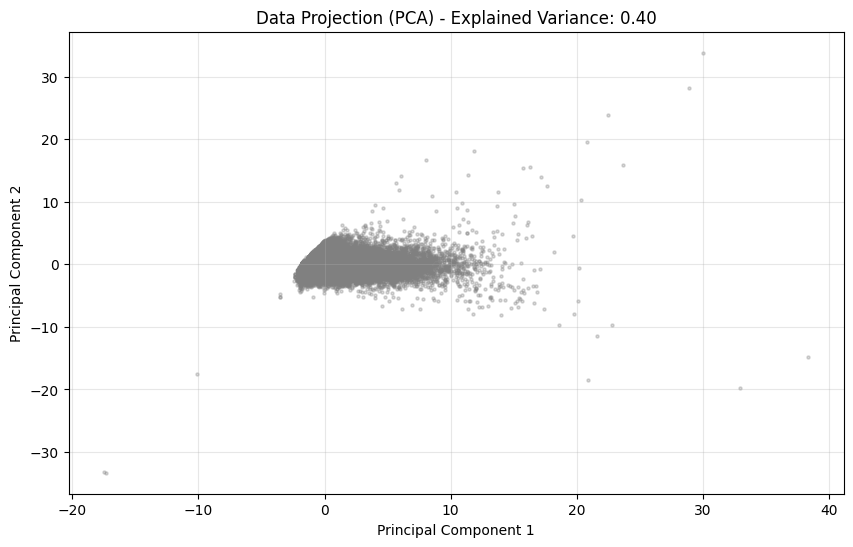

,peering_ratio,prefix_count,fragmentation_index,asn_age_days,security_maturity_score,is_allocated,country_rank,log_provider_count,log_customer_count,log_peer_count,log_total_ip_space,log_ix_count,log_facility_count
0,-0.092918,1.010586,0.822493,1.672383,-0.545129,-1.374777,-0.624738,2.772578,2.002411,0.747132,1.123588,-0.428405,-0.372013
1,0.171064,0.222481,0.044558,2.046222,-0.044492,-1.374777,-0.624738,-0.877658,6.493618,1.738740,0.907269,1.538796,3.831019
2,0.045917,-0.033121,-0.650552,1.564301,1.457420,0.727391,3.518280,2.015086,2.002411,2.142207,2.000426,1.538796,2.158464
3,-0.110517,-0.118321,-0.668006,-1.354927,-0.545129,-1.374777,-0.472701,0.189967,-0.342991,-0.419163,-3.274248,-0.428405,-0.372013
4,-0.040122,-0.097021,0.588724,-0.144482,-0.545129,0.727391,-0.396682,-0.877658,-0.342991,0.747132,-0.662794,-0.428405,-0.372013


In [4]:
# PRE-PROCESSING: LOG & SCALE

# 1. LOG TRANSFORMATION
skewed_features = [
    'provider_count', 'customer_count', 'peer_count', 
    'total_ip_space', 'ix_count', 'facility_count'
]


X_features = df_encoded.copy()


for col in skewed_features:
    if col in X_features.columns:
        X_features[f'log_{col}'] = np.log1p(X_features[col])
        X_features = X_features.drop(columns=[col])

print("Log-transformation applied to count features.")

# 2. SELECT FINAL COLUMNS FOR TRAINING
metadata_cols = ['asn', 'org_name', 'is_drop_listed']
training_cols = [c for c in X_features.columns if c not in metadata_cols]

print(f"\nTraining on {len(training_cols)} Features:")
print(training_cols)

# 3. STANDARD SCALING (Z-Score)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_features[training_cols])

X_scaled_df = pd.DataFrame(X_scaled, columns=training_cols)


print("\nScaling complete. Data range:")
print(X_scaled_df.describe().loc[['min', 'max', 'mean', 'std']].round(2))

# 4. PCA VISUALIZATION (2D Projection)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.3, s=5, c='gray')
plt.title(f"Data Projection (PCA) - Explained Variance: {pca.explained_variance_ratio_.sum():.2f}")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, alpha=0.3)
save_path = "dataset_visualization.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight') 
print(f"Saved high-res plot to '{save_path}'")
plt.show()

display(X_scaled_df.head())

In [5]:
# 1. SETUP
X_input = X_scaled  


# Defining the algorithms
models = {
    "K-Means": KMeans(
        n_clusters=10,         
        n_init=10, 
        random_state=42
    ),

    "BIRCH": Birch(
        threshold=0.5,         
        branching_factor=50,   
        n_clusters=10          
    ),
    
    "GMM (Standard)": GaussianMixture(
        n_components=10,       
        covariance_type='full',
        random_state=42
    )
}


# 2. RUN BENCHMARK
results = []

print(f"Starting benchmark on dataset shape: {X_input.shape}")
print("-" * 60)

for name, model in models.items():
    print(f"Running {name}...", end=" ")
    
    start_time = time.time()
    
    try:
        
        model.fit(X_input)
        
        
        if "GMM" in name:
            labels = model.predict(X_input)
        else:
            labels = model.labels_
            
        elapsed = time.time() - start_time
        
        mask = labels != -1
        X_clean = X_input[mask]
        labels_clean = labels[mask]
        
        unique_labels = set(labels_clean)
        n_clusters = len(unique_labels)
        n_noise = list(labels).count(-1)

        if n_clusters < 2:
            print(f"  -> Warning: Only found {n_clusters} cluster(s). Metrics require >= 2.")
            sil, ch, db = np.nan, np.nan, np.nan
        else:
            print(f"  -> Calculating metrics on {len(X_clean)} valid samples...")

            sil = silhouette_score(X_clean, labels_clean, sample_size=15000, random_state=42)

            ch = calinski_harabasz_score(X_clean, labels_clean)
            db = davies_bouldin_score(X_clean, labels_clean)
        
        print(f"DONE ({elapsed:.4f} s)")
        results.append({
            "Algorithm": name,
            "Time (s)": elapsed,
            "Clusters Found": n_clusters,
            "Noise Points": n_noise,
            "Silhouette": sil,
            "Calinski-Harabasz": ch,
            "Davies-Bouldin": db,
            "Status": "Success"
        })
        
    except Exception as e:
        print("FAILED")
        print(f"  -> Error: {str(e)}")
        results.append({
            "Algorithm": name,
            "Time (s)": float('inf'),
            "Clusters Found": 0,
            "Noise Points": 0,
            "Status": "Failed"
        })


# 3. DISPLAY RESULTS
print("-" * 80)
results_df = pd.DataFrame(results).sort_values(by="Silhouette", ascending=False)
display(results_df)

Starting benchmark on dataset shape: (78643, 13)
------------------------------------------------------------
Running K-Means...   -> Calculating metrics on 78643 valid samples...
DONE (2.2764 s)
Running BIRCH...   -> Calculating metrics on 78643 valid samples...
DONE (20.1895 s)
Running GMM (Standard)...   -> Calculating metrics on 78643 valid samples...
DONE (4.0288 s)
--------------------------------------------------------------------------------


,Algorithm,Time (s),Clusters Found,Noise Points,Silhouette,Calinski-Harabasz,Davies-Bouldin,Status
0,K-Means,2.276365,10,0,0.220181,11516.170247,1.251679,Success
1,BIRCH,20.189525,10,0,0.170664,7563.657179,1.387205,Success
2,GMM (Standard),4.028756,10,0,0.166696,5649.728283,2.529668,Success


In [6]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 1. SETUP
X_input = X_scaled 

# Configuration for the optimization run
# METIS excluded due to inherent topological and balanced-cut mismatches.
tuning_config = {
    "K-Means": {"trials": 50, "active": True},
    "BIRCH":   {"trials": 50, "active": True},
    "GMM":     {"trials": 50, "active": True},
    "HDBSCAN": {"trials": 50, "active": True}
}

# 2. OBJECTIVE FUNCTION
def objective(trial, model_name, X_full):
    X_train = X_full
    limit_n = 20000 # Subsampling limit to prevent memory crashes on Silhouette
    
    try:
        # --- A. K-MEANS ---
        if model_name == "K-Means":
            params = {
                "n_clusters": trial.suggest_int("n_clusters", 4, 10),
                "init": trial.suggest_categorical("init", ["k-means++", "random"]),
                "algorithm": trial.suggest_categorical("algorithm", ["lloyd", "elkan"]),
                "tol": trial.suggest_float("tol", 1e-5, 1e-3, log=True),
                "n_init": 10, 
                "random_state": 42
            }
            model = KMeans(**params)
            labels = model.fit_predict(X_train)

        # --- B. BIRCH ---
        elif model_name == "BIRCH":
            params = {
                "threshold": trial.suggest_float("threshold", 0.01, 1.5, log=True),
                "branching_factor": trial.suggest_int("branching_factor", 10, 150),
                "n_clusters": trial.suggest_int("n_clusters", 4, 10)
            }
            model = Birch(**params)
            labels = model.fit_predict(X_train)

        # --- C. GMM ---
        elif model_name == "GMM":
            params = {
                "n_components": trial.suggest_int("n_components", 4, 10),
                "covariance_type": trial.suggest_categorical("covariance_type", ["full", "diag", "tied", "spherical"]),
                "init_params": trial.suggest_categorical("init_params", ["kmeans", "k-means++", "random"]),
                "random_state": 42
            }
            model = GaussianMixture(**params)
            labels = model.fit_predict(X_train)

        # --- D. HDBSCAN ---
        elif model_name == "HDBSCAN":
            params = {
                "min_cluster_size": trial.suggest_int("min_cluster_size", 5, 200),
                "min_samples": trial.suggest_int("min_samples", 1, 50),
                "cluster_selection_method": trial.suggest_categorical("cluster_selection_method", ['eom', 'leaf']),
                "metric": trial.suggest_categorical("metric", ["euclidean", "manhattan"]),
                "gen_min_span_tree": True
            }
            model = hdbscan.HDBSCAN(**params)
            model.fit(X_train)
            labels = model.labels_
            
            # Use DBCV (Relative Validity) instead of Silhouette
            if len(set(labels) - {-1}) > 1:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore", category=RuntimeWarning)
                    score = getattr(model, 'relative_validity_', -1.0)
                    
                    # If the math collapsed and returned NaN, treat it as a terrible score
                    if math.isnan(score):
                        return -1.0
                    return score
            else:
                return -1.0

        # --- E. METRIC EVALUATION (For Spatial Algorithms) ---
        # Strip out noise (-1) before scoring
        if -1 in labels:
            mask = labels != -1
            X_scored = X_train[mask]
            labels_scored = labels[mask]
        else:
            X_scored = X_train
            labels_scored = labels
            
        if len(set(labels_scored)) < 2:
            return -1.0

        # Calculate Silhouette Score safely for K-Means, BIRCH, and GMM
        if len(X_scored) > limit_n:
             score = silhouette_score(X_scored, labels_scored, sample_size=limit_n, random_state=42)
        else:
             score = silhouette_score(X_scored, labels_scored)
        
        return score

    except Exception as e:
        # If an algorithm crashes due to an impossible parameter combination, safely discard the trial
        return -1.0


# 3. RUN OPTIMIZATION LOOP
best_results = []

print(f"{'Algorithm':<15} | {'Metric Used':<12} | {'Best Score':<10} | {'Hyperparameters'}")
print("-" * 100)

for name, config in tuning_config.items():
    if not config["active"]:
        continue
        
    study = optuna.create_study(direction="maximize")
    func = lambda trial: objective(trial, name, X_input)
    
    try:
        study.optimize(func, n_trials=config["trials"])
        
        # Explicitly log which metric was optimized
        metric_name = "DBCV" if name == "HDBSCAN" else "Silhouette"
        
        best_results.append({
            "Algorithm": name,
            "Target Metric": metric_name,
            "Best Score": study.best_value,
            "Optimal Parameters": study.best_params
        })
        
        # Print progress iteratively
        print(f"{name:<15} | {metric_name:<12} | {study.best_value:.4f}     | {str(study.best_params)[:60]}...")
        
    except KeyboardInterrupt:
        print(f"{name:<15} | SKIPPED      | User Interrupted")


# 4. DISPLAY FINAL LEADERBOARD
print("\n" + "="*35 + " FINAL TUNED RESULTS " + "="*35)
results_df = pd.DataFrame(best_results).sort_values(by="Best Score", ascending=False)
pd.set_option('display.max_colwidth', None)
display(results_df)

Algorithm       | Metric Used  | Best Score | Hyperparameters
----------------------------------------------------------------------------------------------------
K-Means         | Silhouette   | 0.2197     | {'n_clusters': 8, 'init': 'random', 'algorithm': 'lloyd', 't...
BIRCH           | Silhouette   | 0.8556     | {'threshold': 1.4148410641511469, 'branching_factor': 29, 'n...
GMM             | Silhouette   | 0.2059     | {'n_components': 9, 'covariance_type': 'tied', 'init_params'...
HDBSCAN         | DBCV         | 0.1830     | {'min_cluster_size': 148, 'min_samples': 5, 'cluster_selecti...

=================================== FINAL TUNED RESULTS ===================================


,Algorithm,Target Metric,Best Score,Optimal Parameters
1,BIRCH,Silhouette,0.855591,"{'threshold': 1.4148410641511469, 'branching_factor': 29, 'n_clusters': 4}"
0,K-Means,Silhouette,0.219657,"{'n_clusters': 8, 'init': 'random', 'algorithm': 'lloyd', 'tol': 0.000997005769140361}"
2,GMM,Silhouette,0.205927,"{'n_components': 9, 'covariance_type': 'tied', 'init_params': 'kmeans'}"
3,HDBSCAN,DBCV,0.183028,"{'min_cluster_size': 148, 'min_samples': 5, 'cluster_selection_method': 'leaf', 'metric': 'euclidean'}"


In [ ]:
#Run models with optimized settings
winner_models = {
    "BIRCH_Tuned": Birch(
        threshold=1.4646230846909196,
        branching_factor=28,
        n_clusters=5 
    ),

    "K-Means_tuned": KMeans(
        n_clusters=5,
        init='random',          
        n_init=10,            
        random_state=42
    ),

    "GMM_tuned": GaussianMixture(
        n_components=7,       
        covariance_type='full',
        random_state=42
    ),

    "HDBSCAN_tuned": hdbscan.HDBSCAN(
        min_cluster_size=148, 
        min_samples=5, 
        cluster_selection_method='leaf', 
        metric='euclidean'
    )
}


X_train = X_scaled 

final_results = {}

print("\nStarting Final Training...")
print("-" * 50)

for name, model in winner_models.items():
    print(f"Training {name}...", end=" ")
    
    try:
        if "GMM_tuned" in name:
            model.fit(X_train)
            labels = model.predict(X_train)
        else:
            labels = model.fit_predict(X_train)
        
        final_results[name] = labels
        
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        n_noise = list(labels).count(-1)
        
        print(f"DONE.")
        print(f" Found {n_clusters} clusters (Noise points: {n_noise})")
        
        if n_clusters < 2:
            print("Too few clusters found.")
            
    except Exception as e:
        print(f"FAILED: {e}")


Starting Final Training...
--------------------------------------------------
Training BIRCH_Tuned... DONE.
 Found 5 clusters (Noise points: 0)
Training K-Means_tuned... DONE.
 Found 5 clusters (Noise points: 0)
Training GMM_tuned... DONE.
 Found 7 clusters (Noise points: 0)


In [6]:
# 1. THE GMM LAYER
class GaussianMixtureLayer(nn.Module):
    """
    Learns the cluster centers (mu), variances (var), and mixing weights (pi)
    entirely from data, without labels.
    """
    def __init__(self, n_components, n_features):
        super().__init__()
        self.n_components = n_components
        self.n_features = n_features
        
        # PARAMETER 1: Centroids (Mu) - Randomly initialized
        self.mu = nn.Parameter(torch.randn(n_components, n_features))
        
        # PARAMETER 2: Log-Variance
        # Learn log_var to ensure mathematically that variance is always positive.
        # Initialized to 0 means initial variance is 1.0.
        self.log_var = nn.Parameter(torch.zeros(n_components, n_features))
        
        # PARAMETER 3: Mixing Weights (Pi) - All clusters start with equal probability
        self.pi_logits = nn.Parameter(torch.zeros(n_components))

    def forward(self, x):
        """
        Calculates the Negative Log-Likelihood (Loss).
        Goal: Minimize this value to make the data 'fit' the clusters better.
        """
        # Clamp variance to prevent numerical explosion
        log_var = torch.clamp(self.log_var, min=-10, max=10)
        x_expanded = x.unsqueeze(1) 
        mu_expanded = self.mu.unsqueeze(0)
        log_var_expanded = log_var.unsqueeze(0)
        
        # Calculate Gaussian Likelihood
        # Formula: -0.5 * [ (x-mu)^2/var + log(var) + log(2pi) ]
        diff = x_expanded - mu_expanded
        log_prob = -0.5 * ( (diff ** 2) / (torch.exp(log_var_expanded))
                            + log_var_expanded 
                            + np.log(2 * np.pi) )
        

        log_prob_per_component = torch.sum(log_prob, dim=2)
        

        log_pi = torch.log_softmax(self.pi_logits, dim=0)
        final_log_components = log_prob_per_component + log_pi
        

        final_log_likelihood = torch.logsumexp(final_log_components, dim=1)
        
        # Return NLL (Negative Log Likelihood)
        return -torch.mean(final_log_likelihood)

    def predict(self, x):
        #Returns the most likely cluster ID
        with torch.no_grad():
            log_var = torch.clamp(self.log_var, min=-10, max=10)
            x_expanded = x.unsqueeze(1)
            mu_expanded = self.mu.unsqueeze(0)
            log_var_expanded = log_var.unsqueeze(0)
            
            diff = x_expanded - mu_expanded
            log_prob = -0.5 * ( (diff ** 2) / torch.exp(log_var_expanded) + log_var_expanded )
            log_prob_per_component = torch.sum(log_prob, dim=2)
            log_pi = torch.log_softmax(self.pi_logits, dim=0)
            return torch.argmax(log_prob_per_component + log_pi, dim=1)


# 2. THE DEEP NETWORK (Encoder)
class AutoencoderGMM(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, latent_dim=10, n_components=16, dropout=0.1):
        super().__init__()
        
        # --- ENCODER ---
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            
            nn.Linear(hidden_dim // 2, latent_dim),
            #nn.Tanh()
        )
        
        # --- DECODER ---
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(hidden_dim // 2, hidden_dim),
            nn.ReLU(),
            
            nn.Linear(hidden_dim, input_dim) 
        )
        
        # --- GMM LAYER ---
        self.gmm = GaussianMixtureLayer(n_components, latent_dim)

    def forward_reconstruction(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return nn.functional.mse_loss(x_hat, x)

    def forward_clustering(self, x):
        z = self.encoder(x)
        return self.gmm(z)
    
    def get_clusters(self, x):
        z = self.encoder(x)
        return self.gmm.predict(z)


# 3. INITIALIZATION


input_dim = X_scaled.shape[1]

current_seed = random.randint(0, 100000)

# Saved seed: 3093/42(k-means), 74054
print("=" * 40) 
print(f"INITIALIZING RUN WITH SEED: {current_seed}")
print("=" * 40)

torch.manual_seed(current_seed)
np.random.seed(current_seed)
random.seed(current_seed)

model = AutoencoderGMM(
    input_dim=input_dim, 
    hidden_dim=64,     # encoder capacity
    latent_dim=8,      # compressed space size
    n_components=8,   # cluster num
    dropout=0.1 # ratio of neurons to zero out
)


print("Model initialized on CPU:")
print(model)

INITIALIZING RUN WITH SEED: 14934
Model initialized on CPU:
AutoencoderGMM(
  (encoder): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=13, bias=True)
  )
  (gmm): GaussianMixtureLayer()
)


In [ ]:
# 1. SETUP & HYPERPARAMETERS
LEARNING_RATE = 1e-3       
BATCH_SIZE = 1024          
WEIGHT_DECAY = 1e-5        
EPOCHS_STAGE_1 = 50        
EPOCHS_STAGE_2 = 100
PATIENCE = 5               



tensor_x = torch.Tensor(X_scaled)

train_loader = DataLoader(
    TensorDataset(tensor_x), 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=0 
)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

optimizer_ae = optim.Adam(model.parameters(), lr=1e-3)

# SCHEDULER: Reduce LR on Plateau
# If loss doesn't improve for 'patience' epochs, cut LR by half (factor=0.5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=PATIENCE
)


# 2. TRAINING LOOP
print(f"\nStarting Training (Press Ctrl+C to stop early and save)...")
print("-" * 60)

start_time = time.time()
loss_history = []
model.train()

try:
    for epoch in range(EPOCHS_STAGE_1):
        total_loss = 0
        for batch in train_loader:
            x = batch[0]
            optimizer_ae.zero_grad()
            loss = model.forward_reconstruction(x)
            loss.backward()
            optimizer_ae.step()
            total_loss += loss.item()
    
    if (epoch+1) % 5 == 0:
        print(f"   Epoch {epoch+1}/{EPOCHS_STAGE_1} | MSE Loss: {total_loss / len(train_loader):.4f}")


except KeyboardInterrupt:
    print("\nTraining Interrupted by User!")

print("Stage 1 Complete. Latent space is now populated.")


# INTERMISSION: K-MEANS INITIALIZATION
print("\nINITIALIZATION: Running K-Means on Latent Space...")

# 1. Extract all latent vectors
all_z = []
model.eval()
with torch.no_grad():
    for batch in train_loader:
        all_z.append(model.encoder(batch[0]))
full_z = torch.cat(all_z).numpy()

# 2. Run K-Means
kmeans = KMeans(n_clusters=8, n_init=20, random_state=current_seed)
kmeans.fit(full_z)
print(f"   -> K-Means found {len(set(kmeans.labels_))} distinct clusters.")

# 3. Inject centers into GMM
new_centroids = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)
model.gmm.mu.data = new_centroids
model.gmm.log_var.data.fill_(-0.5)
model.gmm.pi_logits.data.fill_(0.0)

print("GMM initialized with K-Means centers.")


# STAGE 2: CLUSTERING TRAINING
print("\nSTAGE 2: Fine-Tuning Clustering (NLL Loss)...")

optimizer_cluster = optim.Adam(model.parameters(), lr=1e-4) 

lambda_rec = 0.45
lambda_gmm = 0.25
lambda_entropy = 0.05

model.train()
for epoch in range(EPOCHS_STAGE_2):
    total_nll = 0
    total_ent = 0
    
    for batch in train_loader:
        x = batch[0]
        optimizer_cluster.zero_grad()
        
        # 1. Reconstruction Loss (The Anchor)
        loss_rec = model.forward_reconstruction(x)
        
        # 2. Get Soft Probabilities
        z = model.encoder(x)
        
        log_var = torch.clamp(model.gmm.log_var, min=-10, max=10)
        x_exp = z.unsqueeze(1)
        mu_exp = model.gmm.mu.unsqueeze(0)
        var_exp = log_var.unsqueeze(0)
        
        diff = x_exp - mu_exp
        log_prob = -0.5 * ((diff**2)/(torch.exp(var_exp)+1e-6) + var_exp + np.log(2*np.pi))
        log_prob_sum = torch.sum(log_prob, dim=2)
        log_pi = torch.log_softmax(model.gmm.pi_logits, dim=0)
        
        log_gamma = log_prob_sum + log_pi
        probs = torch.softmax(log_gamma, dim=1)
        
        # 3. Clustering Loss (NLL)
        loss_nll = -torch.mean(torch.logsumexp(log_gamma, dim=1))
        
        # 4. Entropy Loss (The Sharpening Tool)
        # Entropy = - sum(p * log(p))
        entropy_loss = -torch.sum(probs * torch.log(probs + 1e-9), dim=1).mean()
        
        # TOTAL LOSS
        total_loss = (lambda_gmm * loss_nll) + (lambda_rec * loss_rec) + (lambda_entropy * entropy_loss)
        
        total_loss.backward()
        optimizer_cluster.step()
        
        total_nll += loss_nll.item()
        total_ent += entropy_loss.item()

    if (epoch+1) % 5 == 0:
        with torch.no_grad():
            sample_preds = model.get_clusters(tensor_x[:2000]).numpy()
            n_found = len(set(sample_preds))
        
        print(f"   Epoch {epoch+1}/{EPOCHS_STAGE_2} | NLL: {total_nll/len(train_loader):.2f} | Entropy: {total_ent/len(train_loader):.4f} | Clusters: {n_found}")
    
    scheduler.step(total_nll)


# FINAL CHECK
model.eval()
with torch.no_grad():
    final_preds = model.get_clusters(tensor_x).numpy()
    
unique_clusters = np.unique(final_preds)
print(f"\nTraining Done. Clusters Found: {len(unique_clusters)}")
print(f"Cluster IDs: {unique_clusters}")


Starting Training (Press Ctrl+C to stop early and save)...
------------------------------------------------------------
   Epoch 20/20 | MSE Loss: 0.1158
Stage 1 Complete. Latent space is now populated.

INITIALIZATION: Running K-Means on Latent Space...
   -> K-Means found 8 distinct clusters.
GMM initialized with K-Means centers.

STAGE 2: Fine-Tuning Clustering (NLL Loss)...
   Epoch 5/20 | NLL: 10.58 | Entropy: 0.1100 | Clusters: 7
   Epoch 10/20 | NLL: 8.81 | Entropy: 0.0816 | Clusters: 7
   Epoch 15/20 | NLL: 8.03 | Entropy: 0.0514 | Clusters: 5
   Epoch 20/20 | NLL: 7.56 | Entropy: 0.0442 | Clusters: 5

Training Done. Clusters Found: 8
Cluster IDs: [0 1 2 3 4 5 6 7]


In [181]:
# 1. SETUP & HYPERPARAMETERS
LEARNING_RATE = 1e-3       
BATCH_SIZE = 1024          
WEIGHT_DECAY = 1e-5        
EPOCHS_STAGE_1 = 20        
EPOCHS_STAGE_2 = 30
PATIENCE = 5               



tensor_x = torch.Tensor(X_scaled)

train_loader = DataLoader(
    TensorDataset(tensor_x), 
    batch_size=BATCH_SIZE, 
    shuffle=True,
    num_workers=0 
)

# Optimizer
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

optimizer_ae = optim.Adam(model.parameters(), lr=1e-3)

# SCHEDULER: Reduce LR on Plateau
# If loss doesn't improve for 'patience' epochs, cut LR by half (factor=0.5)
#scheduler = optim.lr_scheduler.ReduceLROnPlateau(
#    optimizer, mode='min', factor=0.5, patience=PATIENCE
#)


# 2. TRAINING LOOP
print(f"\nStarting Training (Press Ctrl+C to stop early and save)...")
print("-" * 60)

start_time = time.time()
loss_history = []
model.train()

try:
    for epoch in range(EPOCHS_STAGE_1):
        total_loss = 0
        for batch in train_loader:
            x = batch[0]
            optimizer_ae.zero_grad()
            loss = model.forward_reconstruction(x)
            loss.backward()
            optimizer_ae.step()
            total_loss += loss.item()
    
    if (epoch+1) % 5 == 0:
        print(f"   Epoch {epoch+1}/{EPOCHS_STAGE_1} | MSE Loss: {total_loss / len(train_loader):.4f}")


except KeyboardInterrupt:
    print("\nTraining Interrupted by User!")

print("Stage 1 Complete. Latent space is now populated.")


# INTERMISSION: K-MEANS INITIALIZATION
print("\nINITIALIZATION: Running K-Means on Latent Space...")

# 1. Extract all latent vectors
all_z = []
model.eval()
with torch.no_grad():
    for batch in train_loader:
        all_z.append(model.encoder(batch[0]))
full_z = torch.cat(all_z).numpy()

# 2. Run K-Means
kmeans = KMeans(n_clusters=8, n_init=20, random_state=current_seed)
kmeans.fit(full_z)
print(f"   -> K-Means found {len(set(kmeans.labels_))} distinct clusters.")

# 3. Inject centers into GMM
new_centroids = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)
model.gmm.mu.data = new_centroids
MIN_VAR = 0.5
MAX_VAR = 5.0
log_variances = []
for i in range(8):  # 8 is your n_components
    # Get all latent points assigned to this cluster
    cluster_points = full_z[kmeans.labels_ == i]
    
    if len(cluster_points) > 1:
        actual_var = np.var(cluster_points, axis=0)
        safe_var = np.clip(actual_var, a_min=MIN_VAR, a_max=MAX_VAR)
        log_variances.append(np.log(safe_var))
    else:
        # Fallback if a cluster is completely empty
        log_variances.append(np.zeros(8)) # 8 is your latent_dim

model.gmm.log_var.data = torch.tensor(np.array(log_variances), dtype=torch.float32)
model.gmm.pi_logits.data.fill_(0.0)

print("GMM initialized with K-Means centers and variances.")


# STAGE 2: CLUSTERING TRAINING
print("\nSTAGE 2: Fine-Tuning Clustering (NLL Loss)...")

optimizer_cluster = optim.Adam(model.parameters(), lr=1e-4) 

lambda_rec = 0.2
lambda_gmm = 1.0
lambda_entropy = 0.8

model.train()
for epoch in range(EPOCHS_STAGE_2):
    total_nll = 0
    total_ent = 0
    
    for batch in train_loader:
        x = batch[0]
        optimizer_cluster.zero_grad()
        
        # 1. Reconstruction Loss (The Anchor)
        loss_rec = model.forward_reconstruction(x)
        
        # 2. Get Soft Probabilities
        z = model.encoder(x)
        
        log_var = torch.clamp(model.gmm.log_var, min=-10, max=10)
        x_exp = z.unsqueeze(1)
        mu_exp = model.gmm.mu.unsqueeze(0)
        var_exp = log_var.unsqueeze(0)
        
        diff = x_exp - mu_exp
        log_prob = -0.5 * ((diff**2)/(torch.exp(var_exp)+1e-6) + var_exp + np.log(2*np.pi))
        log_prob_sum = torch.sum(log_prob, dim=2)
        log_pi = torch.log_softmax(model.gmm.pi_logits, dim=0)
        
        log_gamma = log_prob_sum + log_pi
        probs = torch.softmax(log_gamma, dim=1)
        
        # 3. Clustering Loss (NLL)
        loss_nll = -torch.mean(torch.logsumexp(log_gamma, dim=1))
        
        # 4. Entropy Loss (The Sharpening Tool)
        # Entropy = - sum(p * log(p))
        entropy_loss = -torch.sum(probs * torch.log(probs + 1e-9), dim=1).mean()
        
        # TOTAL LOSS
        total_loss = (lambda_gmm * loss_nll) + (lambda_rec * loss_rec) + (lambda_entropy * entropy_loss)
        
        total_loss.backward()
        optimizer_cluster.step()
        
        total_nll += loss_nll.item()
        total_ent += entropy_loss.item()

    if (epoch+1) % 5 == 0:
        with torch.no_grad():
            sample_preds = model.get_clusters(tensor_x[:2000]).numpy()
            n_found = len(set(sample_preds))
        
        print(f"   Epoch {epoch+1}/{EPOCHS_STAGE_2} | NLL: {total_nll/len(train_loader):.2f} | Entropy: {total_ent/len(train_loader):.4f} | Clusters: {n_found}")


# FINAL CHECK
model.eval()
with torch.no_grad():
    final_preds = model.get_clusters(tensor_x).numpy()
    
unique_clusters = np.unique(final_preds)
print(f"\nTraining Done. Clusters Found: {len(unique_clusters)}")
print(f"Cluster IDs: {unique_clusters}")


Starting Training (Press Ctrl+C to stop early and save)...
------------------------------------------------------------
   Epoch 20/20 | MSE Loss: 0.1089
Stage 1 Complete. Latent space is now populated.

INITIALIZATION: Running K-Means on Latent Space...
   -> K-Means found 8 distinct clusters.
GMM initialized with K-Means centers and variances.

STAGE 2: Fine-Tuning Clustering (NLL Loss)...
   Epoch 5/30 | NLL: 9.96 | Entropy: 0.0727 | Clusters: 7
   Epoch 10/30 | NLL: 8.82 | Entropy: 0.0336 | Clusters: 7
   Epoch 15/30 | NLL: 8.36 | Entropy: 0.0259 | Clusters: 5
   Epoch 20/30 | NLL: 8.07 | Entropy: 0.0221 | Clusters: 5
   Epoch 25/30 | NLL: 7.82 | Entropy: 0.0193 | Clusters: 5
   Epoch 30/30 | NLL: 7.59 | Entropy: 0.0171 | Clusters: 5

Training Done. Clusters Found: 5
Cluster IDs: [0 2 4 5 6]


In [7]:
# 1. Initialize a blank model with the exact same dimensions
model = AutoencoderGMM(
    input_dim=X_scaled.shape[1], 
    hidden_dim=64,     
    latent_dim=8,      
    n_components=8,   
    dropout=0.1 
)

# 2. Load the saved weights into the model
tensor_x = torch.Tensor(X_scaled)
model.load_state_dict(torch.load('optuna_models/dec_gm_trial_42.pth', weights_only=True), strict=False)

# 3. Set to evaluation mode before doing any predictions
model.eval()

AutoencoderGMM(
  (encoder): Sequential(
    (0): Linear(in_features=13, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=32, out_features=64, bias=True)
    (4): ReLU()
    (5): Linear(in_features=64, out_features=13, bias=True)
  )
  (gmm): GaussianMixtureLayer()
)

Generating Improved Cluster Visualization...
Saved high-res plot to 'cluster_visualization_improved.png'


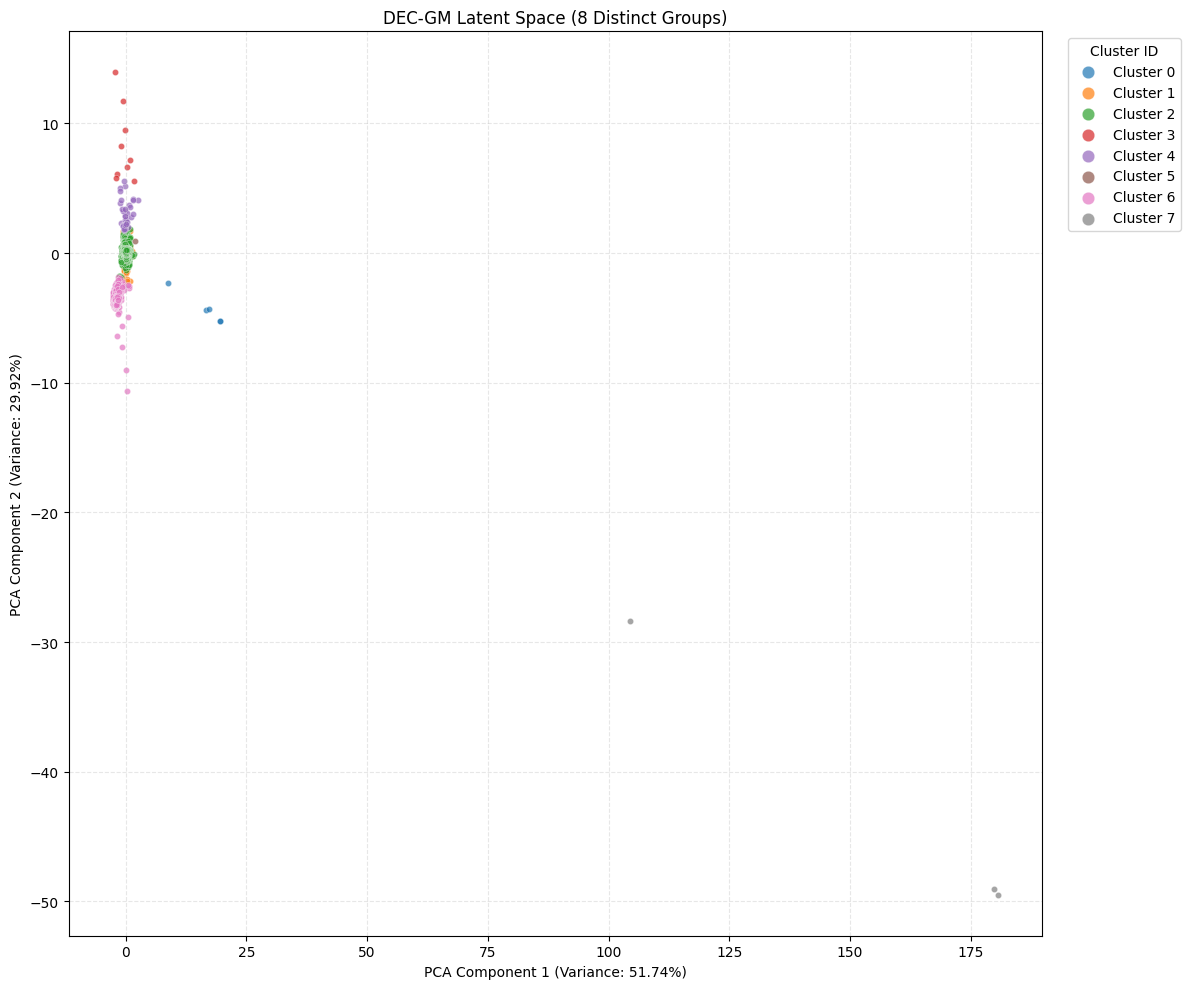

In [19]:
def visualize_clusters(model, data_tensor):
    print("Generating Improved Cluster Visualization...")
    
    # 1. Get Data from Model
    model.eval()
    with torch.no_grad():
        z = model.encoder(data_tensor).numpy()
        labels = model.get_clusters(data_tensor).numpy()
    
    # 2. Squash to 2D
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z)
    
    # 3. Setup Plot
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    
    cmap_name = 'tab10' if n_clusters <= 10 else 'tab20'
    colors = plt.get_cmap(cmap_name)
    
    plt.figure(figsize=(12, 10))
    
    # 4. Plot each cluster explicitly 
    for i, label in enumerate(unique_labels):
        mask = labels == label
        
        plt.scatter(
            z_2d[mask, 0], z_2d[mask, 1],
            color=colors(i % 20),      
            label=f"Cluster {label}",  
            alpha=0.7,                 
            s=20,                      
            edgecolor='white',        
            linewidth=0.3
        )

    # 5. Finalize
    plt.legend(title="Cluster ID", markerscale=2.0, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.title(f"DEC-GM Latent Space ({n_clusters} Distinct Groups)")
    plt.xlabel(f"PCA Component 1 (Variance: {pca.explained_variance_ratio_[0]:.2%})")
    plt.ylabel(f"PCA Component 2 (Variance: {pca.explained_variance_ratio_[1]:.2%})")
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    
    save_path = "cluster_visualization_improved.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True) 
    print(f"Saved high-res plot to '{save_path}'")
    plt.show()

visualize_clusters(model, tensor_x)

In [9]:
def get_soft_probabilities(model, data_tensor):
    """
    Returns a matrix of shape (N_samples, N_clusters)
    where output[i, j] is the probability that point i belongs to cluster j.
    """
    model.eval()
    with torch.no_grad():
        # 1. Compress to Latent Space
        z = model.encoder(data_tensor)
        
        # 2. Get Log-Probabilities from GMM
        x_expanded = z.unsqueeze(1)
        mu_expanded = model.gmm.mu.unsqueeze(0)
        log_var_expanded = model.gmm.log_var.unsqueeze(0)
        
        # Gaussian formula
        log_prob = -0.5 * ( (x_expanded - mu_expanded)**2 / torch.exp(log_var_expanded) 
                            + log_var_expanded + np.log(2 * np.pi) )
        log_prob_sum = torch.sum(log_prob, dim=2)
        
        # Add priors (mixing weights)
        log_pi = torch.log_softmax(model.gmm.pi_logits, dim=0)
        final_log_logits = log_prob_sum + log_pi
        
        # 3. Apply Softmax to get 0.0 - 1.0 range
        probabilities = torch.softmax(final_log_logits, dim=1)
        
    return probabilities.cpu().numpy()


probs = get_soft_probabilities(model, tensor_x)
print(f"Probabilities Shape: {probs.shape}")
print(f"Point 0 Probabilities: {probs[0]}") 

Probabilities Shape: (78643, 8)
Point 0 Probabilities: [1.0326183e-08 2.9376349e-01 6.9989574e-01 7.3813582e-30 6.3400795e-03
 6.3895823e-07 9.5357403e-13 0.0000000e+00]


In [ ]:
def auto_clean_clusters(model, data_tensor, min_size=100, max_dist=0.5):
    """
    Automatically merges tiny clusters and clusters that are too close in Latent Space.
    
    Args:
        model: Trained AutoencoderGMM model
        data_tensor: Input data (torch.Tensor)
        min_size: Clusters smaller than this will be merged into neighbors
        max_dist: Clusters closer than this (Euclidean distance of centroids) will be merged
    """
    print("CLUSTER CLEANING ")
    print(f"   -> Criteria: Size < {min_size} OR Centroid Dist < {max_dist}")
    print("-" * 60)
    
    # 1. Get Initial State
    model.eval()
    with torch.no_grad():
        # Latent centers (Mu) - shape (K, latent_dim)
        mu = model.gmm.mu.cpu().numpy()
        # Initial Hard Labels
        labels = model.get_clusters(data_tensor).numpy()
        original_probs = get_soft_probabilities(model, data_tensor)
        if torch.is_tensor(original_probs):
            original_probs = original_probs.cpu().numpy()


    unique_labels = np.unique(labels)
    merge_map = {lbl: lbl for lbl in unique_labels}
    
    has_changed = True
    iteration = 0
    
    # ITERATIVE MERGING LOOP
    while has_changed:
        has_changed = False
        iteration += 1
        
        # A. Update Counts based on current merge_map
        current_labels = np.array([merge_map[x] for x in labels])
        unique_curr, counts_curr = np.unique(current_labels, return_counts=True)
        active_clusters = [u for u in unique_curr if u != -1]
        
        if len(active_clusters) < 2:
            print("   -> Stopping: Only 1 cluster left (or all noise). Try running the model again, or tweaking model parameters.")
            break

        # B. Get Centroids for ACTIVE clusters
        active_centroids = []
        for cid in active_clusters:
            active_centroids.append(mu[cid]) 
        active_centroids = np.array(active_centroids)

        # --- STEP 1: MERGE CLOSEST PAIRS (Distance Check) ---
        # Calculate distance matrix between active clusters
        dists = cdist(active_centroids, active_centroids, metric='euclidean')
        np.fill_diagonal(dists, np.inf)
        
        min_dist_idx = np.unravel_index(np.argmin(dists), dists.shape)
        dist_val = dists[min_dist_idx]
        
        if dist_val < max_dist:
            # Get actual Cluster IDs (map index back to ID)
            c1 = active_clusters[min_dist_idx[0]]
            c2 = active_clusters[min_dist_idx[1]]
            
            # Merge higher ID into lower ID
            id_keep, id_merge = min(c1, c2), max(c1, c2)
            
            print(f"   [Iter {iteration}] Distance Merge: Cluster {id_merge} -> {id_keep} (Dist: {dist_val:.3f})")
            
            # Update Map: Anyone pointing to id_merge now points to id_keep
            for k, v in merge_map.items():
                if v == id_merge:
                    merge_map[k] = id_keep
            
            has_changed = True
            continue

        # --- STEP 2: MERGE TINY CLUSTERS (Size Check) ---
        tiny_clusters = [u for u, c in zip(unique_curr, counts_curr) if c < min_size and u != -1]
        
        if tiny_clusters:
            target_tiny = tiny_clusters[0] 
            
            idx_tiny = active_clusters.index(target_tiny)
            
            my_dists = dists[idx_tiny] 
            nearest_idx = np.argmin(my_dists)
            nearest_dist = my_dists[nearest_idx]
            nearest_id = active_clusters[nearest_idx]
            
            # Safety: If nearest neighbor is far ( > 2.0), mark as Outlier
            # Otherwise, merge into neighbor.
            fallback_dist = 2.0 
            
            if nearest_dist < fallback_dist:
                print(f"   [Iter {iteration}] Size Merge: Tiny Cluster {target_tiny} (<{min_size}) -> Neighbor {nearest_id} (Dist: {nearest_dist:.3f})")
                new_id = nearest_id
            else:
                print(f"   [Iter {iteration}] Prune: Tiny Cluster {target_tiny} is isolated -> Outlier (-1)")
                new_id = -1
            
            # Update Map
            for k, v in merge_map.items():
                if v == target_tiny:
                    merge_map[k] = new_id
            
            has_changed = True
            continue

    # 3. Finalize Labels
    final_labels = np.array([merge_map[x] for x in labels])

    noise_mask = (final_labels == -1)
    n_noise = np.sum(noise_mask)
    
    # 4. Rescue Noise
    if n_noise > 0:
        # Find which IDs are currently in use
        used_ids = set(np.unique(final_labels)) - {-1}
        
        # Find the lowest non-negative integer NOT in used_ids
        anomaly_id = 0
        while anomaly_id in used_ids:
            anomaly_id += 1
            
        print(f"   -> Rescuing {n_noise} outliers -> Assigned to recycled ID {anomaly_id}")
        
        # Reassign -1 to this new ID
        final_labels[noise_mask] = anomaly_id

        for k, v in merge_map.items():
            if v == -1:
                merge_map[k] = anomaly_id
    else:
        print("   -> No outliers found to rescue.")
    
    max_final_id = max(merge_map.values())
    merged_probs = np.zeros((original_probs.shape[0], max_final_id + 1))
    
    # Add probabilities together for components that merged
    for old_id, new_id in merge_map.items():
        merged_probs[:, new_id] += original_probs[:, old_id]

    # 5. Report Stats
    print("-" * 60)
    print(f" Cleaning Complete.")
    print(f"   Original Clusters: {len(unique_labels)}")
    print(f"   Final Clusters:    {len(set(final_labels) - {-1})}")
    
    return final_labels, merged_probs


clean_labels, clean_probs = auto_clean_clusters(
    model, 
    tensor_x, 
    min_size=100,  # Merges clusters < 100 items
    max_dist=0.25   # Merges clusters closer than 0.5 units
)

# Extract unique IDs from the clean labels
unique_ids = np.unique(clean_labels)
surviving_ids = sorted([uid for uid in unique_ids if uid != -1])

------------------------------------------------------------
 Cleaning Complete.
   Original Clusters: 8
   Final Clusters:    4


Generating Improved Cluster Visualization...
Saved high-res plot to 'cluster_visualization_cleaned.png'


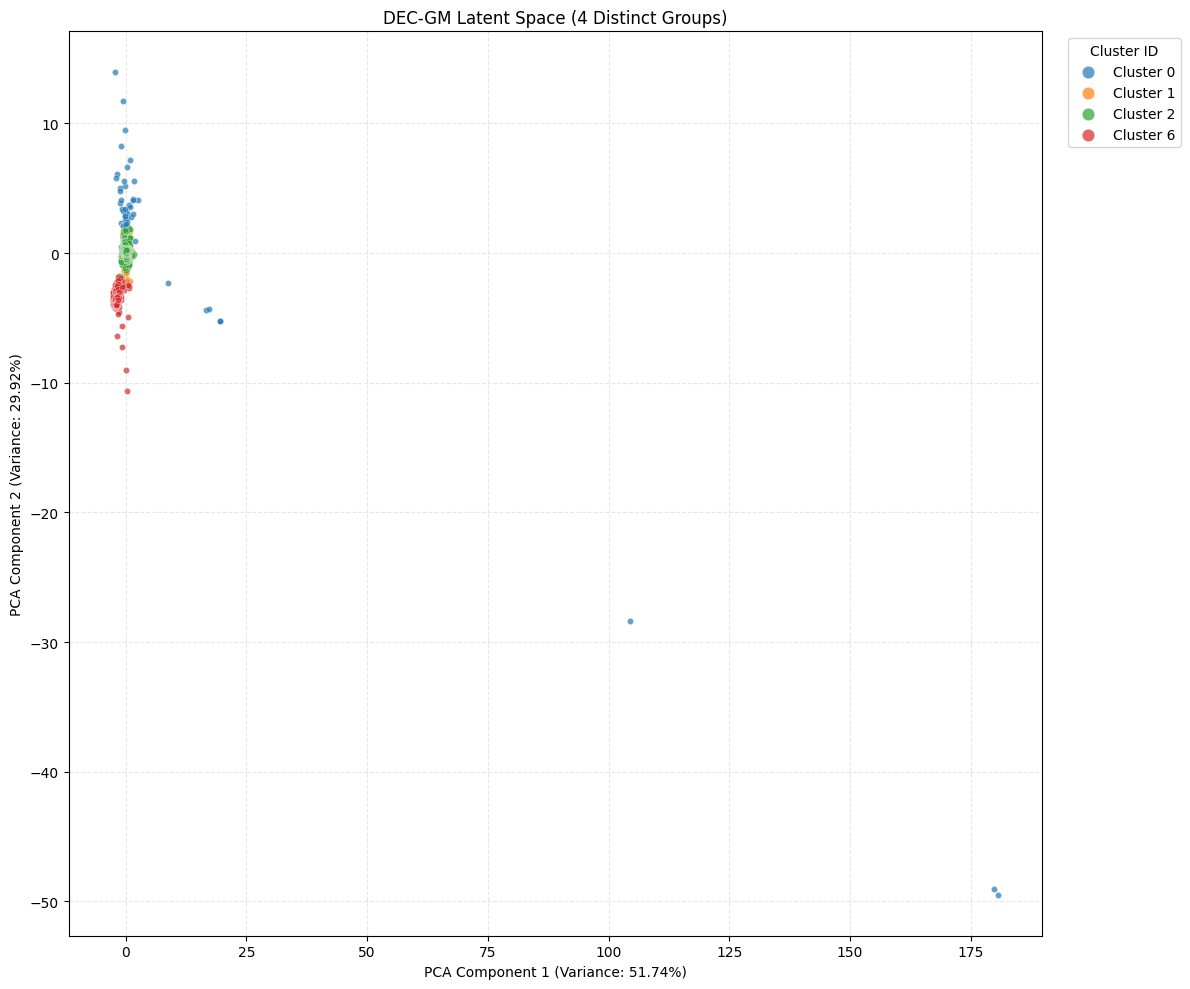

In [20]:
def visualize_clusters_post_merge(model, data_tensor, clean_labels):
    print("Generating Improved Cluster Visualization...")
    
    # 1. Get Data from Model
    model.eval()
    with torch.no_grad():
        z = model.encoder(data_tensor).numpy()
    
    labels = clean_labels
    
    # 2. Squash to 2D
    pca = PCA(n_components=2)
    z_2d = pca.fit_transform(z)
    
    # 3. Setup Plot
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    
    cmap_name = 'tab10' if n_clusters <= 10 else 'tab20'
    colors = plt.get_cmap(cmap_name)
    
    plt.figure(figsize=(12, 10))
    
    # 4. Plot each cluster explicitly 
    for i, label in enumerate(unique_labels):
        mask = labels == label
        
        plt.scatter(
            z_2d[mask, 0], z_2d[mask, 1],
            color=colors(i % 20),      
            label=f"Cluster {label}",  
            alpha=0.7,                 
            s=20,                      
            edgecolor='white',        
            linewidth=0.3
        )

    # 5. Finalize
    plt.legend(title="Cluster ID", markerscale=2.0, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.title(f"DEC-GM Latent Space ({n_clusters} Distinct Groups)")
    plt.xlabel(f"PCA Component 1 (Variance: {pca.explained_variance_ratio_[0]:.2%})")
    plt.ylabel(f"PCA Component 2 (Variance: {pca.explained_variance_ratio_[1]:.2%})")
    plt.grid(True, alpha=0.3, linestyle='--')
    plt.tight_layout()
    save_path = "cluster_visualization_cleaned.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True) 
    print(f"Saved high-res plot to '{save_path}'")
    plt.show()

    

visualize_clusters_post_merge(model, tensor_x, clean_labels)

ANALYZING SOFT PROBABILITIES...
------------------------------------------------------------
Partition Entropy: 0.2086
   -> Result: BALANCED (Good separation with realistic uncertainty)
Saved high-res plot to 'confidence_plot.png'


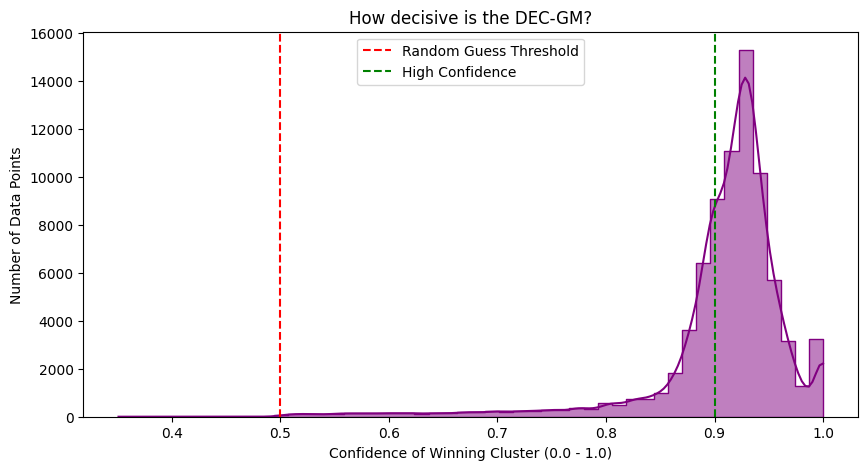

In [21]:
def analyze_soft_clustering(probs_array):
    print("ANALYZING SOFT PROBABILITIES...")
    print("-" * 60)
    
    # 1. Get Probabilities & Clean them
    # Filter out empty probability columns (clusters that disappeared)
    active_cols = np.sum(probs_array, axis=0) > 0
    clean_probs = probs_array[:, active_cols]
    
    # 2. Calculate Partition Entropy
    n_classes = clean_probs.shape[1]
    point_entropies = entropy(clean_probs.T)
    partition_entropy = np.mean(point_entropies) / np.log(n_classes)
    
    print(f"Partition Entropy: {partition_entropy:.4f}")
    if partition_entropy < 0.1:
        print("   -> Result: VERY CRISP (Model behaves almost like K-Means)")
    elif partition_entropy < 0.3:
        print("   -> Result: BALANCED (Good separation with realistic uncertainty)")
    else:
        print("   -> Result: FUZZY (Significant overlap between clusters)")

    # 3. Visualization: Certainty Distribution
    max_probs = np.max(clean_probs, axis=1) 
    
    plt.figure(figsize=(10, 5))
    sns.histplot(max_probs, bins=50, kde=True, color='purple', element="step")
    plt.axvline(0.5, color='red', linestyle='--', label='Random Guess Threshold')
    plt.axvline(0.9, color='green', linestyle='--', label='High Confidence')
    
    plt.title("How decisive is the DEC-GM?")
    plt.xlabel("Confidence of Winning Cluster (0.0 - 1.0)")
    plt.ylabel("Number of Data Points")
    plt.legend()
    save_path = "confidence_plot.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True) 
    print(f"Saved high-res plot to '{save_path}'")
    plt.show()
    
    return clean_probs, point_entropies

from scipy.stats import entropy
dgmm_probs, uncertainties = analyze_soft_clustering(clean_probs)

In [ ]:
optuna.logging.set_verbosity(optuna.logging.INFO)

# ==========================================
# SETUP
# ==========================================
SEED = 42
TARGET_ENTROPY = 0.20  
TARGET_CLUSTERS = [4, 5]

# Create a folder to keep the 100 model files organized
os.makedirs("optuna_models", exist_ok=True)

tensor_x = torch.Tensor(X_scaled)
train_loader = DataLoader(TensorDataset(tensor_x), batch_size=1024, shuffle=True, num_workers=0)

# ==========================================
# OBJECTIVE FUNCTION
# ==========================================
def objective(trial):
    l_rec = trial.suggest_float("lambda_rec", 0.5, 2.0, log=True)
    l_gmm = trial.suggest_float("lambda_gmm", 0.5, 5.0, log=True)
    l_ent = trial.suggest_float("lambda_entropy", 0.01, 0.5, log=True)
    
    torch.manual_seed(SEED)
    np.random.seed(SEED)
    random.seed(SEED)
    
    model = AutoencoderGMM(input_dim=input_dim, hidden_dim=64, latent_dim=8, n_components=8, dropout=0.1)
    optimizer_ae = optim.Adam(model.parameters(), lr=1e-3)
    optimizer_cluster = optim.Adam(model.parameters(), lr=1e-4) 
    
    # Stage 1: AE Pre-training 
    model.train()
    for epoch in range(25): 
        for batch in train_loader:
            x = batch[0]
            optimizer_ae.zero_grad()
            loss = model.forward_reconstruction(x)
            loss.backward()
            optimizer_ae.step()
            
    # Stage 2: K-Means Init
    model.eval()
    all_z = [model.encoder(batch[0]) for batch in train_loader]
    full_z = torch.cat(all_z).detach().numpy()
    
    kmeans = KMeans(n_clusters=8, n_init=20, random_state=SEED).fit(full_z)
    model.gmm.mu.data = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32)
    model.gmm.log_var.data.fill_(-0.5)
    model.gmm.pi_logits.data.fill_(0.0)
    
    # Stage 3: Clustering Fine-tuning 
    model.train()
    for epoch in range(50): 
        for batch in train_loader:
            x = batch[0]
            optimizer_cluster.zero_grad()
            
            loss_rec = model.forward_reconstruction(x)
            z = model.encoder(x)
            
            log_var = torch.clamp(model.gmm.log_var, min=-10, max=10)
            diff = z.unsqueeze(1) - model.gmm.mu.unsqueeze(0)
            var_exp = log_var.unsqueeze(0)
            
            log_prob = -0.5 * ((diff**2)/(torch.exp(var_exp)+1e-6) + var_exp + np.log(2*np.pi))
            log_gamma = torch.sum(log_prob, dim=2) + torch.log_softmax(model.gmm.pi_logits, dim=0)
            probs = torch.softmax(log_gamma, dim=1)
            
            loss_nll = -torch.mean(torch.logsumexp(log_gamma, dim=1))
            entropy_loss = -torch.sum(probs * torch.log(probs + 1e-9), dim=1).mean()
            
            total_loss = (l_gmm * loss_nll) + (l_rec * loss_rec) + (l_ent * entropy_loss)
            total_loss.backward()
            optimizer_cluster.step()
            
    # Stage 4: Cleanup & Metrics
    model.eval()
    clean_labels, merged_probs = auto_clean_clusters(model, tensor_x, min_size=100, max_dist=0.25)
    
    active_cols = np.sum(merged_probs, axis=0) > 0
    clean_active_probs = merged_probs[:, active_cols]
    n_classes = clean_active_probs.shape[1]
    
    if n_classes > 1:
        point_entropies = entropy(clean_active_probs.T)
        average_entropy = np.mean(point_entropies) # raw average
        partition_entropy = average_entropy / np.log(n_classes) # normalized score
    else:
        average_entropy = 0.0
        partition_entropy = 0.0

    # ==========================================
    # SCORING & SAVING LOGIC 
    # ==========================================
    entropy_penalty = abs(partition_entropy - TARGET_ENTROPY)
    cluster_penalty = 100.0 if n_classes not in TARGET_CLUSTERS else 0.0
    
    trial.set_user_attr("clusters", n_classes)
    trial.set_user_attr("avg_entropy", float(average_entropy))
    trial.set_user_attr("partition_entropy", float(partition_entropy))
    
    if 0.10 <= partition_entropy <= 0.30 and n_classes in TARGET_CLUSTERS:
        trial.set_user_attr("perfect_match", True)
    else:
        trial.set_user_attr("perfect_match", False)

    torch.save(model.state_dict(), f"optuna_models/dec_gm_trial_{trial.number}.pth")
            
    return entropy_penalty + cluster_penalty

# ==========================================
# RUN OPTIMIZATION
# ==========================================
print("Starting Optuna Deep Clustering Search...")
study = optuna.create_study(direction="minimize") 
study.optimize(objective, n_trials=50) 

print("\n" + "="*60)
print(" SEARCH COMPLETE - FINAL REPORT")
print("="*60)

# Extract trials that hit the strict perfect criteria
perfect_trials = [t for t in study.trials if t.user_attrs.get("perfect_match", False)]

if len(perfect_trials) > 0:
    print(f"Found {len(perfect_trials)} trials that perfectly matched your criteria!")
    results = []
    for t in perfect_trials:
        results.append({
            "Match Type": "PERFECT",
            "Trial": t.number,
            "Lambda Rec": t.params["lambda_rec"],
            "Lambda GMM": t.params["lambda_gmm"],
            "Lambda Entropy": t.params["lambda_entropy"],
            "Clusters": t.user_attrs["clusters"],
            "Avg Point Entropy": t.user_attrs["avg_entropy"],          
            "Partition Entropy": t.user_attrs["partition_entropy"]
        })
    results_df = pd.DataFrame(results).sort_values(by="Partition Entropy")
    display(results_df)

else:
    # THE FALLBACK: Fetch the mathematically closest trial
    best = study.best_trial
    print("No configurations met the strict 4-5 cluster AND 0.1-0.3 entropy criteria.")
    print("However, here is the CLOSEST configuration Optuna found:\n")
    
    fallback_data = [{
        "Match Type": "CLOSEST FALLBACK",
        "Trial": best.number,
        "Lambda Rec": best.params["lambda_rec"],
        "Lambda GMM": best.params["lambda_gmm"],
        "Lambda Entropy": best.params["lambda_entropy"],
        "Clusters": best.user_attrs["clusters"],
        "Avg Point Entropy": best.user_attrs["avg_entropy"],
        "Partition Entropy": best.user_attrs["partition_entropy"]
    }]
    
    display(pd.DataFrame(fallback_data))
    
    print(f"\nYou can load this model's weights from: optuna_models/dec_gm_trial_{best.number}.pth")

[I 2026-05-12 13:49:20,359] A new study created in memory with name: no-name-fc3a8f10-048a-49b6-9cbc-0c94b571ccfd


Starting Optuna Deep Clustering Search...


[I 2026-05-12 13:50:28,797] Trial 0 finished with value: 0.14637022363872554 and parameters: {'lambda_rec': 0.5452655231061434, 'lambda_gmm': 2.205432315442714, 'lambda_entropy': 0.028125924279137755}. Best is trial 0 with value: 0.14637022363872554.
[I 2026-05-12 13:51:37,816] Trial 1 finished with value: 0.06064590687340754 and parameters: {'lambda_rec': 0.9490885881636756, 'lambda_gmm': 1.6652815830615968, 'lambda_entropy': 0.11925865103182934}. Best is trial 1 with value: 0.06064590687340754.
[I 2026-05-12 13:52:45,460] Trial 2 finished with value: 0.17973454897622487 and parameters: {'lambda_rec': 0.5307537307421383, 'lambda_gmm': 0.6298739782614637, 'lambda_entropy': 0.3634665452857502}. Best is trial 1 with value: 0.06064590687340754.
[I 2026-05-12 13:53:52,556] Trial 3 finished with value: 0.027005687145767093 and parameters: {'lambda_rec': 0.9184419843362288, 'lambda_gmm': 0.9419341284009741, 'lambda_entropy': 0.08367470891963798}. Best is trial 3 with value: 0.027005687145767


 SEARCH COMPLETE - FINAL REPORT
Found 32 trials that perfectly matched your criteria!


,Match Type,Trial,Lambda Rec,Lambda GMM,Lambda Entropy,Clusters,Avg Point Entropy,Partition Entropy
31,PERFECT,49,1.195842,0.502324,0.086483,4,0.162257,0.117043
16,PERFECT,26,1.338208,0.501018,0.081868,4,0.172601,0.124505
21,PERFECT,34,0.914389,0.664775,0.099967,4,0.196617,0.141829
28,PERFECT,45,1.293303,0.630760,0.086091,4,0.212332,0.153165
5,PERFECT,9,0.531348,0.898417,0.125119,4,0.221683,0.159911
23,PERFECT,38,1.484203,0.595197,0.075800,4,0.225094,0.162371
13,PERFECT,23,0.760334,0.507696,0.065406,4,0.229988,0.165901
10,PERFECT,20,0.779750,1.789871,0.242221,4,0.230640,0.166372
15,PERFECT,25,0.869410,1.180646,0.148511,4,0.243525,0.175667
24,PERFECT,40,0.941264,0.827884,0.097997,4,0.252535,0.182166


{'lambda_rec': 0.01800683404515937, 'lambda_gmm': 3.822148314971295, 'lambda_entropy': 0.010260033081716085} trial 42

RUNNING FILTERED STATS (Cleaned Data Only)...
------------------------------------------------------------
CONFIDENCE METRICS:
   -> Average Assignment Confidence: 0.9079
   -> Ambiguous Points (<70% sure):  2225 / 78643 (2.8%)


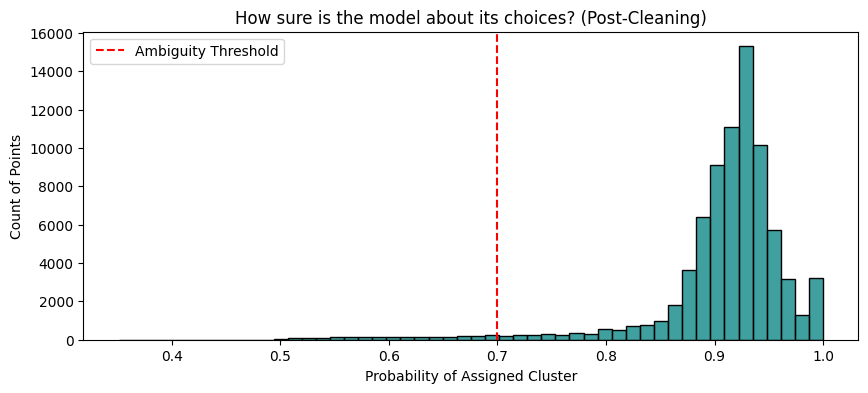

Analyzing 4 Surviving Clusters

Measuring Overlap (Empirical Bhattacharyya Distance)...
Saved high-res plot to 'cluster_overlap.png'


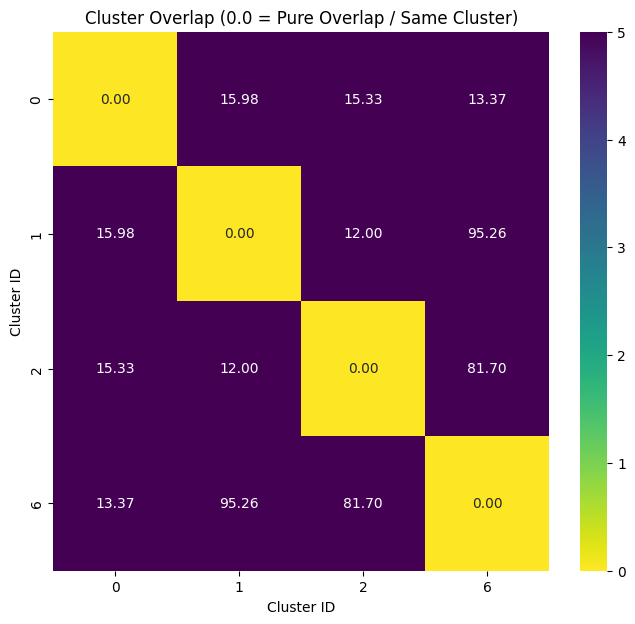


 SEPARABILITY TEST (Cleaned Clusters Only):
   -> RF Accuracy on Cleaned Data: 99.45%


array([[ 0.        , 15.97521591, 15.32536983, 13.36769199],
       [15.97521591,  0.        , 11.99861526, 95.25881958],
       [15.32536983, 11.99861526,  0.        , 81.70346069],
       [13.36769199, 95.25881958, 81.70346069,  0.        ]])

In [22]:
def advanced_cluster_stats(model, data_tensor, clean_labels, clean_probs, surviving_ids):
    print("RUNNING FILTERED STATS (Cleaned Data Only)...")
    print("-" * 60)
    
    # 1. Get the Physical Centroids/Variances from the model
    model.eval()
    with torch.no_grad():
        all_mu = model.gmm.mu.cpu().numpy()
        all_var = torch.exp(model.gmm.log_var).cpu().numpy()
        
    # --- 1. CONFIDENCE ANALYSIS ---
    max_probs = np.max(clean_probs, axis=1)
    
    avg_conf = np.mean(max_probs)
    ambiguous_count = np.sum(max_probs < 0.7) 
    
    print(f"CONFIDENCE METRICS:")
    print(f"   -> Average Assignment Confidence: {avg_conf:.4f}")
    print(f"   -> Ambiguous Points (<70% sure):  {ambiguous_count} / {len(data_tensor)} ({ambiguous_count/len(data_tensor):.1%})")
    
    # Plot Confidence Histogram
    plt.figure(figsize=(10, 4))
    sns.histplot(max_probs, bins=50, kde=False, color='teal')
    plt.axvline(0.7, color='red', linestyle='--', label='Ambiguity Threshold')
    plt.title("How sure is the model about its choices? (Post-Cleaning)")
    plt.xlabel("Probability of Assigned Cluster")
    plt.ylabel("Count of Points")
    plt.legend()
    plt.show()

    # 2. Determine Survivors
    print(f"Analyzing {len(surviving_ids)} Surviving Clusters")
    n_k = len(surviving_ids)

    model.eval()
    with torch.no_grad():
        z = model.encoder(data_tensor).cpu().numpy()
        
    # 2. Calculate the true, post-merge means and variances
    empirical_mu = {}
    empirical_var = {}
    
    for cid in surviving_ids:
        cluster_points = z[clean_labels == cid]
        
        # Calculate the empirical mean and variance
        empirical_mu[cid] = np.mean(cluster_points, axis=0)
        # Add 1e-6 to variance to prevent division by zero in perfect clusters
        empirical_var[cid] = np.var(cluster_points, axis=0) + 1e-6
    
    # --- PART A: BHATTACHARYYA DISTANCE (The Heatmap) ---
    print("\nMeasuring Overlap (Empirical Bhattacharyya Distance)...")
    dist_matrix = np.zeros((n_k, n_k))
    
    for i, cid_i in enumerate(surviving_ids):
        for j, cid_j in enumerate(surviving_ids):
            if i == j: 
                dist_matrix[i, j] = 0.0
                continue
            
            # Extract true parameters for the pair
            mu_i, var_i = empirical_mu[cid_i], empirical_var[cid_i]
            mu_j, var_j = empirical_mu[cid_j], empirical_var[cid_j]
            
            # Bhattacharyya Formula
            sigma_avg = (var_i + var_j) / 2
            term1 = (1/8) * np.sum((mu_i - mu_j)**2 / sigma_avg)
            
            det_sigma_avg = np.prod(sigma_avg)
            det_sigma_i = np.prod(var_i)
            det_sigma_j = np.prod(var_j)
            
            term2 = (1/2) * np.log((det_sigma_avg + 1e-10) / (np.sqrt(det_sigma_i * det_sigma_j) + 1e-10))
            
            dist_matrix[i, j] = term1 + term2

    # Plot Heatmap
    plt.figure(figsize=(8, 7))
    sns.heatmap(
        dist_matrix, 
        cmap='viridis_r', 
        annot=True, fmt=".2f", vmin=0, vmax=5.0,
        xticklabels=surviving_ids, 
        yticklabels=surviving_ids
    )
    plt.title("Cluster Overlap (0.0 = Pure Overlap / Same Cluster)")
    plt.xlabel("Cluster ID")
    plt.ylabel("Cluster ID")
    save_path = "cluster_overlap.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True) 
    print(f"Saved high-res plot to '{save_path}'")
    plt.show()

    # --- PART B: RF CHECK ON SURVIVORS (Using clean_labels) ---
    # We drop any noise points (-1) before training the Random Forest
    mask = clean_labels != -1
    
    # We must also ensure data_tensor is on CPU to convert to numpy
    X_filtered = data_tensor[mask].cpu().numpy() if torch.is_tensor(data_tensor) else data_tensor[mask]
    y_filtered = clean_labels[mask]
    
    print("\n SEPARABILITY TEST (Cleaned Clusters Only):")
    X_train, X_test, y_train, y_test = train_test_split(X_filtered, y_filtered, test_size=0.3, random_state=42)
    
    rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
    rf.fit(X_train, y_train)
    acc = rf.score(X_test, y_test)
    print(f"   -> RF Accuracy on Cleaned Data: {acc:.2%}")

    return dist_matrix


# RUNNING THE FUNCTION (Pass the clean variables!)
advanced_cluster_stats(
    model=model, 
    data_tensor=tensor_x, 
    clean_labels=clean_labels, 
    clean_probs=clean_probs, 
    surviving_ids=surviving_ids
)

In [14]:
def profile_clusters(model, data_tensor, original_df, surviving_ids, custom_labels):
    print("GENERATING CLUSTER PROFILES...")
    
    if custom_labels is not None:
        preds = custom_labels
    else:
        model.eval()
        with torch.no_grad():
            z = model.encoder(data_tensor)
            preds = model.gmm.predict(z).numpy()
    
    print(original_df.columns)
    df_profile = original_df.copy()
    df_profile['Cluster'] = preds
    
    numeric_cols = original_df.select_dtypes(include=['number']).columns.tolist()
    
    
    df_profile = df_profile[df_profile['Cluster'].isin(surviving_ids)]
    
    # Calculate Means per Cluster
    cluster_means = df_profile.groupby('Cluster')[numeric_cols].mean()
    
    # Calculate Global Mean (for comparison)
    global_mean = original_df[numeric_cols].mean()
    
    # Calculate "Relative Importance"
    # (Cluster Mean - Global Mean) / Global Mean
    relative_imp = (cluster_means - global_mean) / global_mean
    

    print("\nCLUSTER AVERAGES (Real Units):")
    display(cluster_means.T.style.background_gradient(cmap='coolwarm', axis=1))
    
    print("\nRELATIVE DIFFERENCE (Blue = Below Avg, Red = Above Avg):")
    display(relative_imp.T.style.background_gradient(cmap='vlag', axis=1, vmin=-2, vmax=2))
    
    return cluster_means, relative_imp


means, relative = profile_clusters(model, tensor_x, df, surviving_ids=surviving_ids, custom_labels=clean_labels)

GENERATING CLUSTER PROFILES...
Index(['asn', 'country', 'provider_count', 'customer_count', 'peer_count',
       'peering_ratio', 'total_ip_space', 'prefix_count',
       'fragmentation_index', 'ix_count', 'facility_count', 'net_type',
       'status_rir', 'asn_age_days', 'is_drop_listed',
       'security_maturity_score', 'is_allocated', 'country_rank'],
      dtype='object')

CLUSTER AVERAGES (Real Units):


Cluster,0,1,2,6
asn,39401.089286,128210.905777,137699.936872,150362.192611
provider_count,5.821429,1.910833,2.150520,1.246413
customer_count,507.946429,0.190527,2.333550,2.255022
peer_count,154.910714,1.416440,13.753057,20.918580
peering_ratio,23.144589,0.432119,2.989202,6.283236
total_ip_space,37733449.267857,17117.067460,31584.765782,258.571019
prefix_count,1207.089286,3.731223,5.373122,0.227403
fragmentation_index,28.938438,2.421869,2.002539,0.002730
ix_count,17.446429,0.206457,0.939168,0.680775
facility_count,33.446429,0.196686,0.877227,0.774749



RELATIVE DIFFERENCE (Blue = Below Avg, Red = Above Avg):


Cluster,0,1,2,6
asn,-0.708655,-0.051965,0.018201,0.111830
provider_count,1.840640,-0.067585,0.049373,-0.391797
customer_count,246.858922,-0.907030,0.138686,0.100366
peer_count,13.873933,-0.863999,0.320516,1.008522
peering_ratio,8.828154,-0.816504,0.269339,1.668123
total_ip_space,711.081867,-0.676977,-0.403952,-0.995120
prefix_count,216.299724,-0.328307,-0.032733,-0.959063
fragmentation_index,12.937231,0.166412,-0.035544,-0.998685
ix_count,23.149247,-0.714223,0.299992,-0.057675
facility_count,47.257577,-0.716214,0.265691,0.117833


In [15]:
# ASSEMBLE THE BEST MODELS
classic_models = {
    "K-Means": KMeans(n_clusters=5, init='random', n_init=10, random_state=42),
    "BIRCH": Birch(threshold=1.4646230846909196, branching_factor=28, n_clusters=5),
    "Standard GMM": GaussianMixture(n_components=7, covariance_type='full', random_state=42)
}

# RUN BENCHMARK
comparison_results = []
model_predictions = pd.DataFrame()

print("STARTING FINAL SHOWDOWN...")
print("-" * 60)

# --- A. RUN CLASSIC MODELS ---
for name, algorithm in classic_models.items():
    print(f"Running {name}...", end=" ")
    start = time.time()
    
    try:
        if hasattr(algorithm, 'fit_predict'):
            labels = algorithm.fit_predict(X_scaled)
        else:
            algorithm.fit(X_scaled)
            labels = algorithm.predict(X_scaled)
            
        elapsed = time.time() - start
        model_predictions[name] = labels
        
        if -1 in labels:
            mask = labels != -1
            score_data = X_scaled[mask]
            score_labels = labels[mask]
            noise_pct = (len(labels) - len(score_labels)) / len(labels)
        else:
            score_data = X_scaled
            score_labels = labels
            noise_pct = 0.0

        sample_size = 15000 
        
        if len(set(score_labels)) > 1:
            sil = silhouette_score(score_data, score_labels, sample_size=sample_size, random_state=42)
            ch = calinski_harabasz_score(score_data, score_labels)
            db = davies_bouldin_score(score_data, score_labels)
        else:
            sil, ch, db = -1, -1, -1
            
        if hasattr(algorithm, 'predict_proba'):
            classic_probs = algorithm.predict_proba(X_scaled)
            point_ent = entropy(classic_probs.T)
            part_entropy = np.mean(point_ent) / np.log(classic_probs.shape[1])
        else:
            part_entropy = 0.0 
            
        actual_clusters = len(set(score_labels))
        print(f"DONE ({elapsed:.1f}s) -> Found {actual_clusters} clusters")
        
        comparison_results.append({
            "Model": name,
            "Clusters": actual_clusters,
            "Noise %": f"{noise_pct:.1%}",
            "Silhouette": sil,
            "Calinski-H": ch,
            "Davies-B": db,
            "Partition Entropy": part_entropy, 
            "Time (s)": elapsed
        })
        
    except Exception as e:
        print(f"FAILED: {e}")

# --- PART B: ADD DEEP GMM ---
print("Running DEC-GM (Inference)...", end=" ")
start = time.time()

clean_dgmm_labels = clean_labels
elapsed = time.time() - start

model_predictions["DEC-GM"] = clean_dgmm_labels

mask = clean_dgmm_labels != -1
if np.sum(mask) > 0:
    X_clean_metric = X_scaled[mask]
    labels_clean_metric = clean_dgmm_labels[mask]
    
    sil = silhouette_score(X_clean_metric, labels_clean_metric, sample_size=15000, random_state=42)
    ch = calinski_harabasz_score(X_clean_metric, labels_clean_metric)
    db = davies_bouldin_score(X_clean_metric, labels_clean_metric)
    
    active_cols = np.sum(clean_probs, axis=0) > 0
    safe_clean_probs = clean_probs[:, active_cols]
    
    point_entropies = entropy(safe_clean_probs.T)
    avg_entropy = np.mean(point_entropies) / np.log(safe_clean_probs.shape[1])
else:
    sil, ch, db, avg_entropy = -1, -1, -1, 0.0

print(f"DONE. ({elapsed:.1f}s)")
print(f"   -> Final Clusters: {len(set(clean_dgmm_labels) - {-1})}")

# ADD TO RESULTS
comparison_results.append({
    "Model": "DEC-GM",
    "Clusters": len(set(clean_dgmm_labels) - {-1}),
    "Noise %": f"{(np.sum(~mask)/len(mask)):.1%}", 
    "Silhouette": sil,
    "Calinski-H": ch,
    "Davies-B": db,
    "Partition Entropy": avg_entropy,
    "Time (s)": elapsed
})

# DISPLAY LEADERBOARD
print("\n" + "="*30 + " FINAL LEADERBOARD " + "="*30)
leaderboard = pd.DataFrame(comparison_results).set_index("Model")

display(leaderboard.sort_values(by="Silhouette", ascending=False).style.background_gradient(cmap='Greens', subset=['Silhouette', 'Calinski-H']))

STARTING FINAL SHOWDOWN...
------------------------------------------------------------
Running K-Means... DONE (0.3s) -> Found 5 clusters
Running BIRCH... DONE (4.5s) -> Found 5 clusters
Running Standard GMM... DONE (2.2s) -> Found 7 clusters
Running DEC-GM (Inference)... DONE. (0.0s)
   -> Final Clusters: 4

============================== FINAL LEADERBOARD ==============================


,Clusters,Noise %,Silhouette,Calinski-H,Davies-B,Partition Entropy,Time (s)
Model,,,,,,,
BIRCH,5,0.0%,0.524398,8084.523824,0.795176,0.000000,4.538671
K-Means,5,0.0%,0.216329,11858.882182,1.568146,0.000000,0.301562
Standard GMM,7,0.0%,0.164886,6949.024269,2.445564,0.007660,2.224182
DEC-GM,4,0.0%,0.137763,5103.747404,1.669009,0.208611,0.000039


GENERATING CLUSTER ATLAS (2x2 Projection)...
Saved high-res plot to 'cluster_visualization_comparison.png'


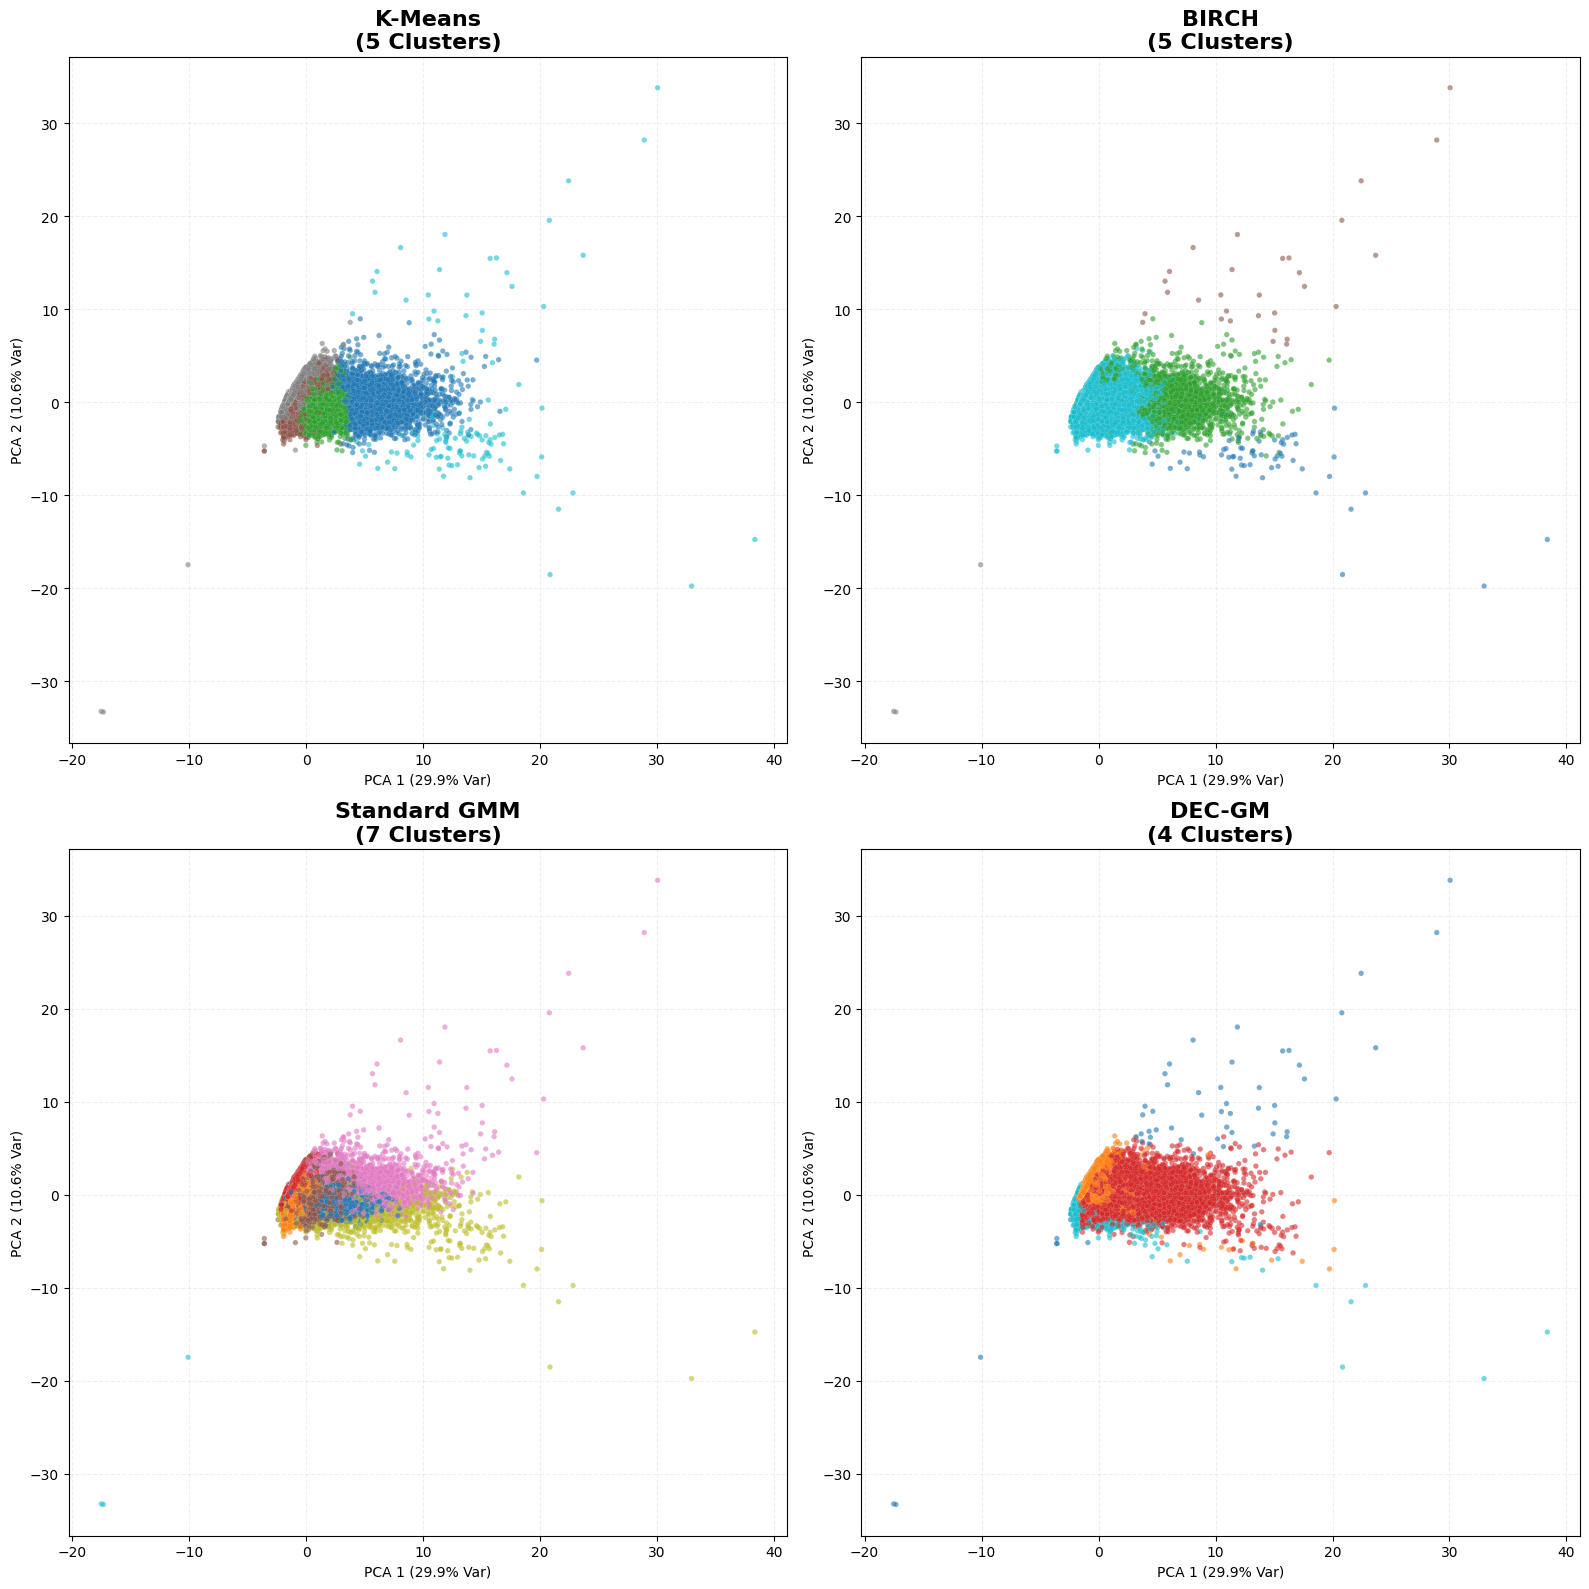

In [23]:
def visualize_four_models(X_data, predictions_df):
    print("GENERATING CLUSTER ATLAS (2x2 Projection)...")
    
    # 1. Reduce Dimensions (PCA)
    pca = PCA(n_components=2)
    X_2d = pca.fit_transform(X_data)
    
    # 2. Setup Dynamic Grid
    models = predictions_df.columns
    n_models = len(models)
    
    cols = 2
    rows = math.ceil(n_models / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(16, 8 * rows))
    axes = axes.flatten()
    
    # 3. Plot Each Model
    for i, model_name in enumerate(models):
        # Ensure labels are a numpy array for easy masking
        labels = predictions_df[model_name].values
        n_clusters = len(set(labels) - {-1}) 
        
        # Create masks for standard points vs noise
        valid_mask = labels != -1
        noise_mask = labels == -1
        
        # Plot A: Valid Clusters
        axes[i].scatter(
            X_2d[valid_mask, 0], X_2d[valid_mask, 1], 
            c=labels[valid_mask], 
            cmap='tab10', 
            s=15, 
            alpha=0.6,
            edgecolor='w',
            linewidth=0.1
        )
        
        # Plot B: Noise/Outliers (If any exist)
        if np.sum(noise_mask) > 0:
            axes[i].scatter(
                X_2d[noise_mask, 0], X_2d[noise_mask, 1], 
                c='dimgray',   # Dull gray color for noise
                marker='x',    # Distinct marker
                s=10, 
                alpha=0.4,
                label='Noise (-1)'
            )
            axes[i].legend(loc='upper right', fontsize=10)
        
        axes[i].set_title(f"{model_name}\n({n_clusters} Clusters)", fontsize=16, fontweight='bold')
        axes[i].set_xlabel(f"PCA 1 ({pca.explained_variance_ratio_[0]:.1%} Var)")
        axes[i].set_ylabel(f"PCA 2 ({pca.explained_variance_ratio_[1]:.1%} Var)")
        axes[i].grid(True, alpha=0.2, linestyle='--')

    # Hide any unused subplots if you have an odd number of models
    for j in range(len(models), len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    save_path = "cluster_visualization_comparison.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True) 
    print(f"Saved high-res plot to '{save_path}'")
    plt.show()

# RUN THE VISUALIZATION
visualize_four_models(X_scaled, model_predictions)

CALCULATING MODEL CONSENSUS (Adjusted Mutual Information)...
Saved high-res plot to 'pairwise_agreement.png'


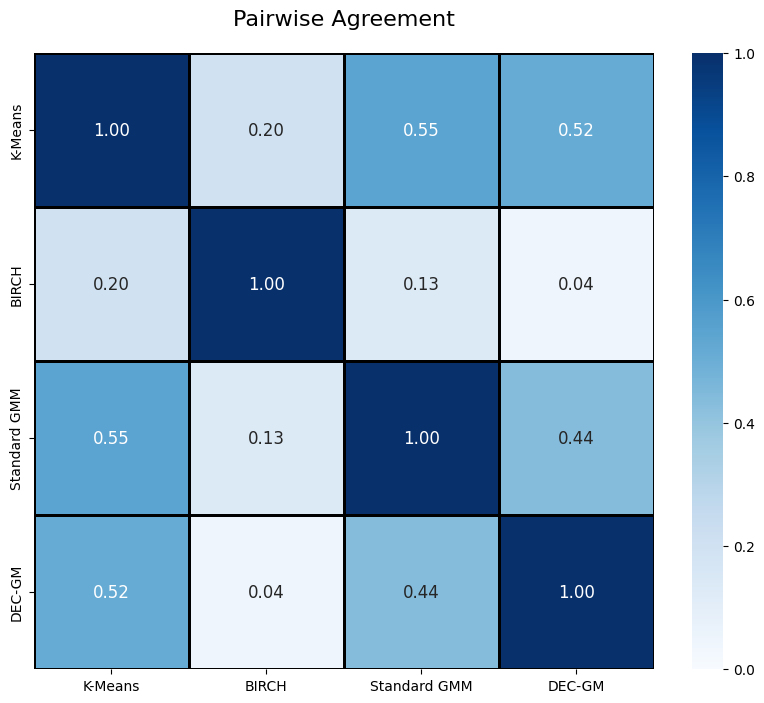

In [18]:
def plot_consensus_heatmap(predictions_df):
    print("CALCULATING MODEL CONSENSUS (Adjusted Mutual Information)...")
    
    models = predictions_df.columns
    corr_matrix = pd.DataFrame(index=models, columns=models, dtype=float)
    
    # Calculate Pairwise Agreement
    for m1 in models:
        for m2 in models:
            if m1 == m2:
                corr_matrix.loc[m1, m2] = 1.0
            else:
                score = adjusted_mutual_info_score(predictions_df[m1], predictions_df[m2])
                corr_matrix.loc[m1, m2] = score
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(
        corr_matrix, 
        annot=True, 
        fmt=".2f", 
        cmap="Blues", 
        linewidths=1.0,
        linecolor='black',
        vmin=0, vmax=1,
        annot_kws={"size": 12}
    )
    plt.title("Pairwise Agreement", fontsize=16, pad=20)
    save_path = "pairwise_agreement.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight', transparent=True) 
    print(f"Saved high-res plot to '{save_path}'")
    plt.show()

plot_consensus_heatmap(model_predictions)

In [54]:
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances

def calculate_advanced_metrics(X_data, labels, n_neighbors=10):
    # 1. k-NN CONSISTENCY (Manifold Metric)
    nn = NearestNeighbors(n_neighbors=n_neighbors + 1)
    nn.fit(X_data)
    
    indices = nn.kneighbors(X_data, return_distance=False)
    
    match_count = 0
    total_neighbors = 0
    
    for i in range(len(X_data)):
        my_label = labels[i]
        neighbor_indices = indices[i, 1:] 
        neighbor_labels = labels[neighbor_indices]
        
        matches = np.sum(neighbor_labels == my_label)
        match_count += matches
        total_neighbors += n_neighbors
        
    knn_consistency = match_count / total_neighbors

    # 2. DUNN INDEX (Separation Metric)
    unique_labels = np.unique(labels)
    unique_labels = unique_labels[unique_labels != -1] # Skip noise
    
    if len(unique_labels) < 2:
        return knn_consistency, 0.0
    
    # A. Calculate Diameters (Max intra-cluster distance)
    max_diameter = 0
    cluster_centers = []
    
    for lbl in unique_labels:
        cluster_points = X_data[labels == lbl]
        if len(cluster_points) > 1:
            if len(cluster_points) > 1000:
                cluster_points = cluster_points[np.random.choice(len(cluster_points), 1000, replace=False)]
            
            dists = pairwise_distances(cluster_points)
            max_diameter = max(max_diameter, np.max(dists))
            
        cluster_centers.append(np.mean(cluster_points, axis=0))
    
    # B. Calculate Inter-Cluster Distances (Min separation)
    min_inter_dist = np.inf
    cluster_centers = np.array(cluster_centers)
    
    
    for i, l1 in enumerate(unique_labels):
        for j, l2 in enumerate(unique_labels):
            if i >= j: continue
            
            c1_points = X_data[labels == l1]
            c2_points = X_data[labels == l2]
            
            # Heavy computation: Euclidean distances between two groups
            # Optimization: Use centroids to check if they are close first
            c_dist = np.linalg.norm(cluster_centers[i] - cluster_centers[j])
            
            # Only calculate full point distance if centroids are somewhat close
            if c_dist < max_diameter * 2: 
                if len(c1_points) > 200: 
                    c1_points = c1_points[np.random.choice(len(c1_points), 200, replace=False)]
                if len(c2_points) > 200: 
                    c2_points = c2_points[np.random.choice(len(c2_points), 200, replace=False)]
                
                d = np.min(pairwise_distances(c1_points, c2_points))
                min_inter_dist = min(min_inter_dist, d)
            else:
                min_inter_dist = min(min_inter_dist, c_dist)

    if max_diameter == 0:
        dunn_index = 0.0
    else:
        dunn_index = min_inter_dist / max_diameter
        
    return knn_consistency, dunn_index

print("\nCALCULATING ADVANCED METRICS...")
for model_name in model_predictions.columns:
    lbls = model_predictions[model_name].values
    
    mask = lbls != -1
    if np.sum(mask) < 2: continue
    
    knn_score, dunn_score = calculate_advanced_metrics(X_scaled[mask], lbls[mask])
    
    print(f"{model_name:<15} | k-NN Consistency: {knn_score:.4f} | Dunn Index: {dunn_score:.4f}")


CALCULATING ADVANCED METRICS...
K-Means         | k-NN Consistency: 0.9770 | Dunn Index: 0.0058
BIRCH           | k-NN Consistency: 0.9871 | Dunn Index: 0.0150
Standard GMM    | k-NN Consistency: 0.9307 | Dunn Index: 0.0059
DEC-GM          | k-NN Consistency: 0.9930 | Dunn Index: 0.0106


In [29]:
# ==========================================
# 1. SAVE CLUSTERING RESULTS TO CSV
# ==========================================
# Create a copy of the original dataset
results_df = df.copy()

# Append the predicted labels from all models (K-Means, BIRCH, Standard GMM, Deep GMM)
for model_name in model_predictions.columns:
    results_df[f"{model_name}_Cluster"] = model_predictions[model_name]

# Export to CSV
csv_filename = 'all_models_clustering_results.csv'
results_df.to_csv(csv_filename, index=False)
print(f"Successfully saved clustering results to '{csv_filename}'")

Successfully saved clustering results to 'all_models_clustering_results.csv'


In [57]:
# ==========================================
# 2. SAVE NEURAL NETWORK WEIGHTS
# ==========================================
# Save the state_dict (weights and biases) of the trained PyTorch model
weights_filename = 'model_weights_4_clusters_seed_58342.pth'
torch.save(model.state_dict(), weights_filename)
print(f"Successfully saved Neural Network weights to '{weights_filename}'")

Successfully saved Neural Network weights to 'model_weights_4_clusters_seed_58342.pth'


In [17]:
if 'HOME' not in os.environ:
    os.environ['HOME'] = os.environ.get('USERPROFILE', 'C:\\')

import ip2asn



print("Loading IP-address database...")
i2a = ip2asn.IP2ASN(r"D:\ML uni\raw data\ip2asn-combined.tsv")

# =====================================================================
# 2. ENTROPY CALCULATION
# =====================================================================
# H = -sum(p * log(p))
calculated_entropies = -np.sum(clean_probs * np.log(clean_probs + 1e-9), axis=1)

# Average entropy on the entire dataset
average_entropy = np.mean(calculated_entropies)
high_entropy_count = np.sum(calculated_entropies > 0.25)

print("\n" + "=" * 45)
print(f" MODEL STATS")
print("=" * 45)
print(f" Total number of autonomous systems (AS): {len(calculated_entropies)}")
print(f" Average entropy:           {average_entropy:.4f}")
print(f" AS in the 'gray area' (H > 0.5): {high_entropy_count}")
print("=" * 45 + "\n")


# 3. DICT FORMATION
asn_array = df['asn'].values   
cluster_array = clean_dgmm_labels   

model_results = {}
for asn, cluster, entropy in zip(asn_array, cluster_array, calculated_entropies):
    model_results[int(asn)] = {
        'cluster': cluster,
        'entropy': float(entropy)
    }

print(f"{len(model_results)} AS profiles successfully initialized.\n")


# 4. ROUTE ANALYSIS
def analyze_route(txt_filepath):
    print(f"Analyzing route from file: {txt_filepath}")
    print("-" * 45)
    print("| ASN    | Cluster Number | Entropy |")
    print("-" * 45)
    
    seen_asns = set()
    
    try:
        with open(txt_filepath, 'r') as file:
            for line in file:
                ip_address = line.strip()
                if not ip_address:
                    continue
                
                
                record = i2a.lookup_address(ip_address)
                if not record or record.get('ASN') == '0':
                    continue 
                
                asn_num = int(record['ASN'])
                
                if asn_num in seen_asns:
                    continue
                seen_asns.add(asn_num)
            

                if asn_num in model_results:
                    cluster = model_results[asn_num]['cluster']
                    entropy = f"{model_results[asn_num]['entropy']:.4f}"
                else:
                    cluster = "5 (Unknown)"
                    entropy = "N/A"
                
                print(f"| {asn_num:<6} | {str(cluster):<14} | {entropy:<7} |")
                
        print("-" * 45)
        
    except FileNotFoundError:
        print(f"Error: File '{txt_filepath}' not found.")

Loading IP-address database...

 MODEL STATS
 Total number of autonomous systems (AS): 78643
 Average entropy:           0.2892
 AS in the 'gray area' (H > 0.5): 52566

78643 AS profiles successfully initialized.

